# Detalhes da regressão logística e exploração de características

objetivos de aprendizado:
- criar list comprehensions em Python
- descrever como funciona a regressão logística
- formular as versões sigmóide e logit da regressão logística
- utilizar a seleção univariada para encontrar características importantes
- personalizar plotagens com a API Matplotlib
- definir o limite de decisão linear de uma regressão logística

In [1]:
import seaborn as sns  
from sklearn.linear_model import LogisticRegression
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl 
mpl.rcParams['figure.dpi'] = 400

df = pd.read_csv('Data/Chapter_1_cleaned_data.csv')

In [2]:
features_response = df.columns.tolist()
features_response[:5]

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE']

In [3]:
features_response[-5:]

['EDUCATION_CAT', 'graduate school', 'high school', 'others', 'university']

In [4]:
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'graduate school', 'high school', 'none',  'others', 'university', 'EDUCATION_CAT']
items_to_remove

['ID',
 'SEX',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'graduate school',
 'high school',
 'none',
 'others',
 'university',
 'EDUCATION_CAT']

In [5]:
features_response = [item for item in features_response if item not in items_to_remove]
features_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_1',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [6]:
corr = df[features_response].corr()
corr.iloc[0:5, 0:5]

,LIMIT_BAL,EDUCATION,MARRIAGE,AGE,PAY_1
LIMIT_BAL,1.000000,-0.232688,-0.109232,0.149157,-0.273396
EDUCATION,-0.232688,1.000000,-0.149563,0.179035,0.112653
MARRIAGE,-0.109232,-0.149563,1.000000,-0.415119,0.020723
AGE,0.149157,0.179035,-0.415119,1.000000,-0.044277
PAY_1,-0.273396,0.112653,0.020723,-0.044277,1.000000


<Axes: >

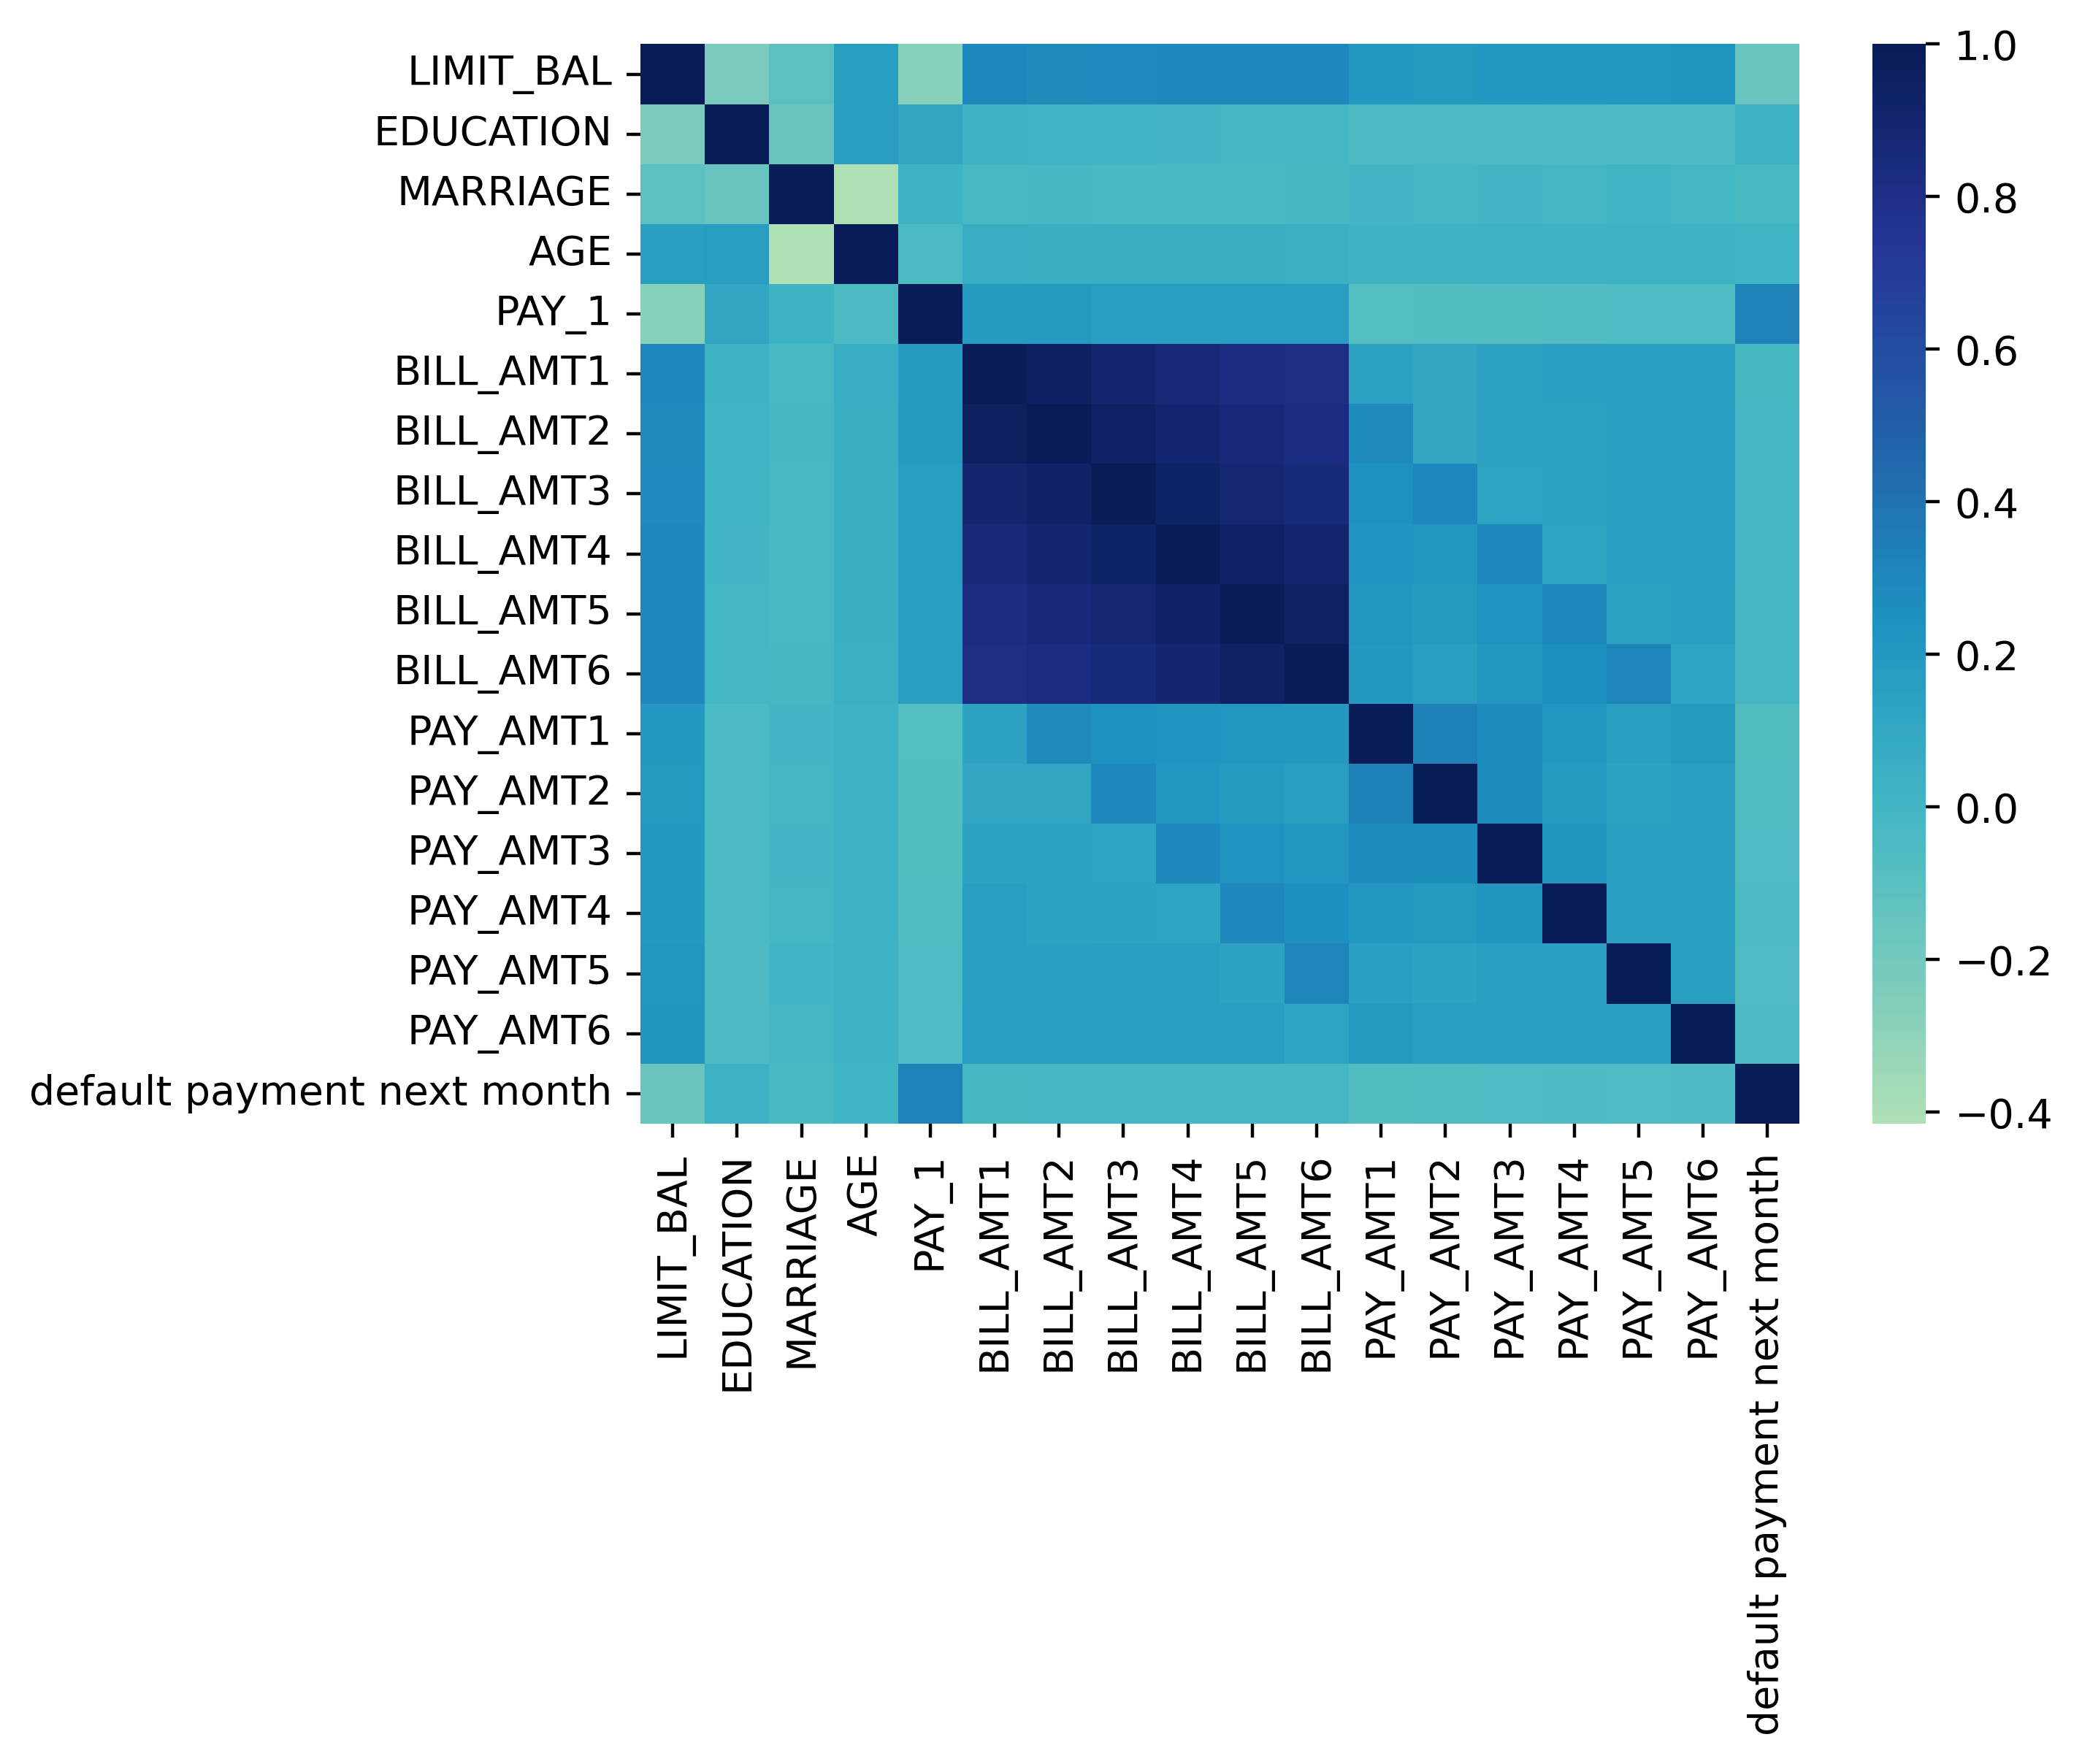

In [7]:
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, cmap='YlGnBu', center=0)


In [8]:
X = df[features_response].iloc[:, :-1].values
y = df[features_response].iloc[:, -1].values
print(X.shape, y.shape)

(26664, 17) (26664,)


In [9]:
from sklearn.feature_selection import f_classif
[f_stat, f_p_value] = f_classif(X, y)

In [10]:
f_test_df = pd.DataFrame({'Feature': features_response[:-1], 'F statistic': f_stat, 'p value': f_p_value}) 
f_test_df.sort_values('p value')

,Feature,F statistic,p value
4,PAY_1,3156.672300,0.000000e+00
0,LIMIT_BAL,651.324071,5.838366e-142
11,PAY_AMT1,140.612679,2.358354e-32
12,PAY_AMT2,101.408321,8.256124e-24
13,PAY_AMT3,90.023873,2.542641e-21
15,PAY_AMT5,85.843295,2.090120e-20
16,PAY_AMT6,80.420784,3.219565e-19
14,PAY_AMT4,79.640021,4.774112e-19
1,EDUCATION,32.637768,1.122175e-08
2,MARRIAGE,14.202266,1.645262e-04


In [11]:
from sklearn.feature_selection import SelectPercentile

selector = SelectPercentile(percentile=20, score_func=f_classif)

selector.fit(X, y)


,score_func,<function f_c...x7f9b62f29da0>
,percentile,20


In [12]:
best_feature_ix = selector.get_support()
best_feature_ix

array([ True, False, False, False,  True, False, False, False, False,
       False, False,  True,  True, False, False, False, False])

In [13]:
features = features_response[:-1]

In [14]:
best_features = [features[counter] for counter in range(len(features)) if best_feature_ix[counter]]
best_features

['LIMIT_BAL', 'PAY_1', 'PAY_AMT1', 'PAY_AMT2']

In [15]:
overall_default_rate = df['default payment next month'].mean()
overall_default_rate

np.float64(0.2217971797179718)

In [16]:
group_by_pay_mean_y = df.groupby('PAY_1').agg({'default payment next month': np.mean})
group_by_pay_mean_y

/tmp/ipykernel_2809/1928172233.py:1: FutureWarning: The provided callable <function mean at 0x7f9bc07b11c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  group_by_pay_mean_y = df.groupby('PAY_1').agg({'default payment next month': np.mean})


,default payment next month
PAY_1,
-2,0.131664
-1,0.170002
0,0.128295
1,0.336400
2,0.694701
3,0.773973
4,0.682540
5,0.434783
6,0.545455


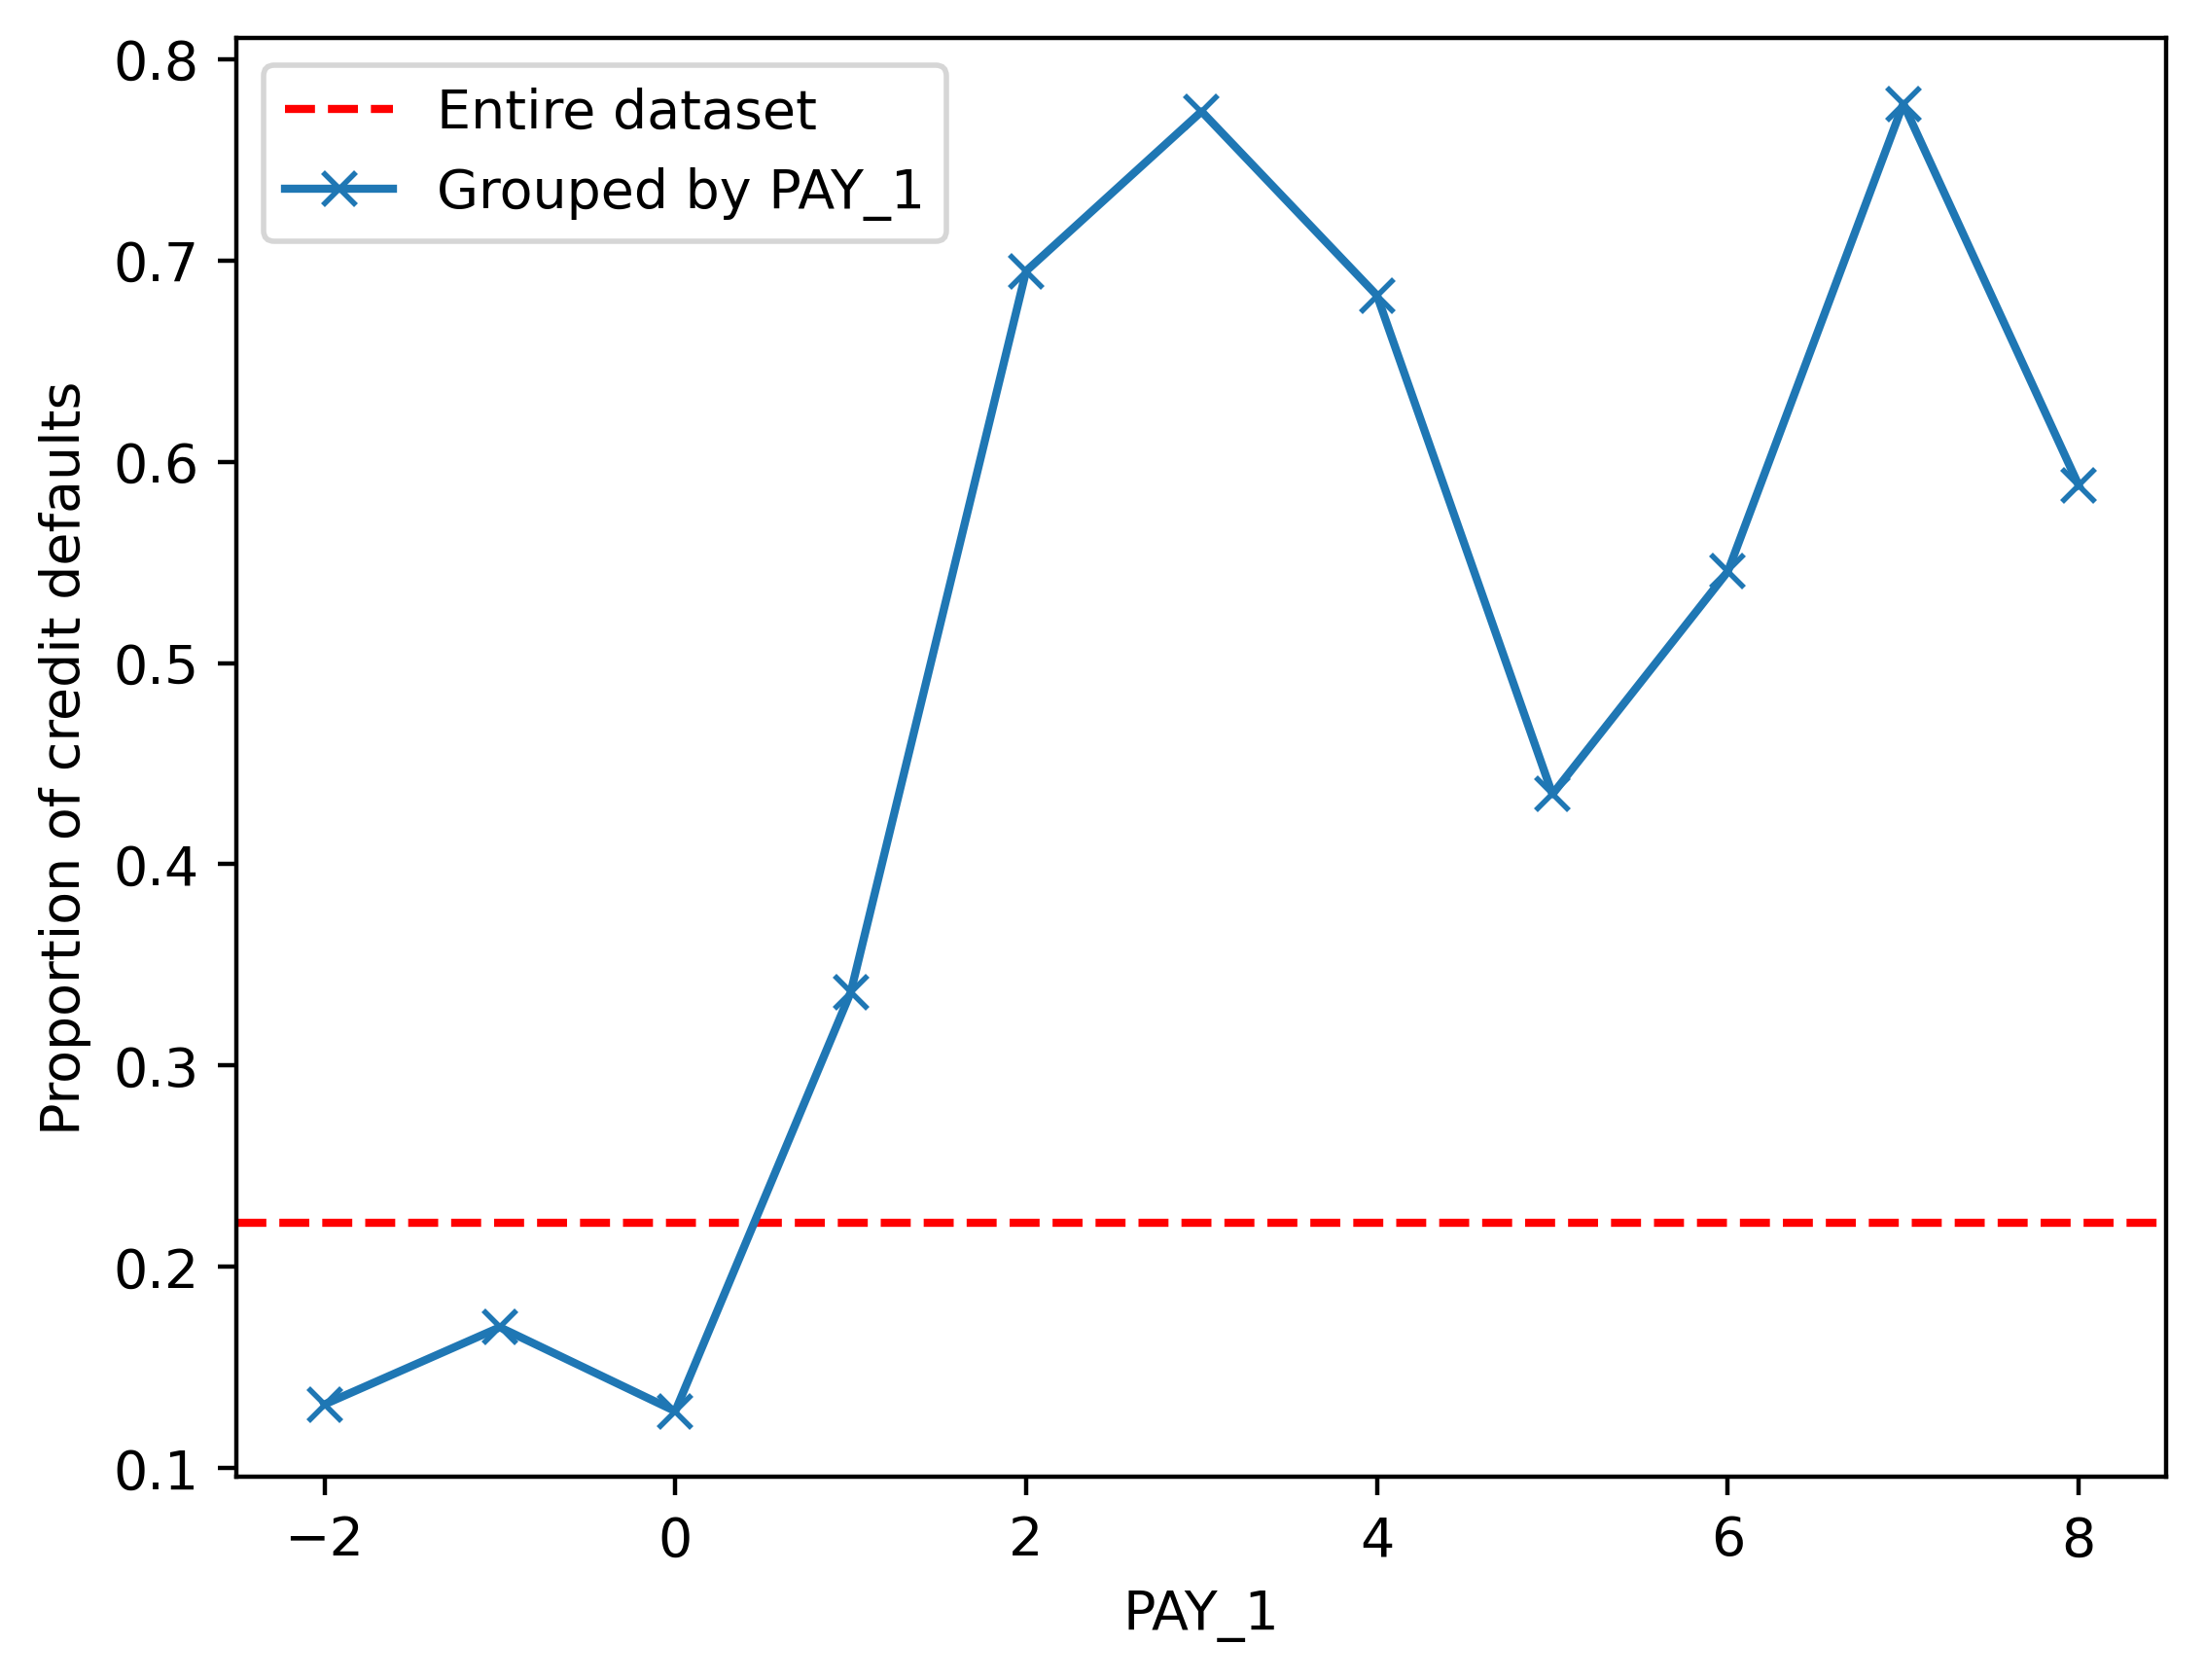

In [17]:
axes = plt.axes()
axes.axhline(overall_default_rate, color='red', linestyle='--')
group_by_pay_mean_y.plot(marker='x', legend=False, ax=axes)
axes.set_ylabel('Proportion of credit defaults')
axes.legend(['Entire dataset', 'Grouped by PAY_1'])

Text(0.5, 1.0, 'Credit limits by response variable')

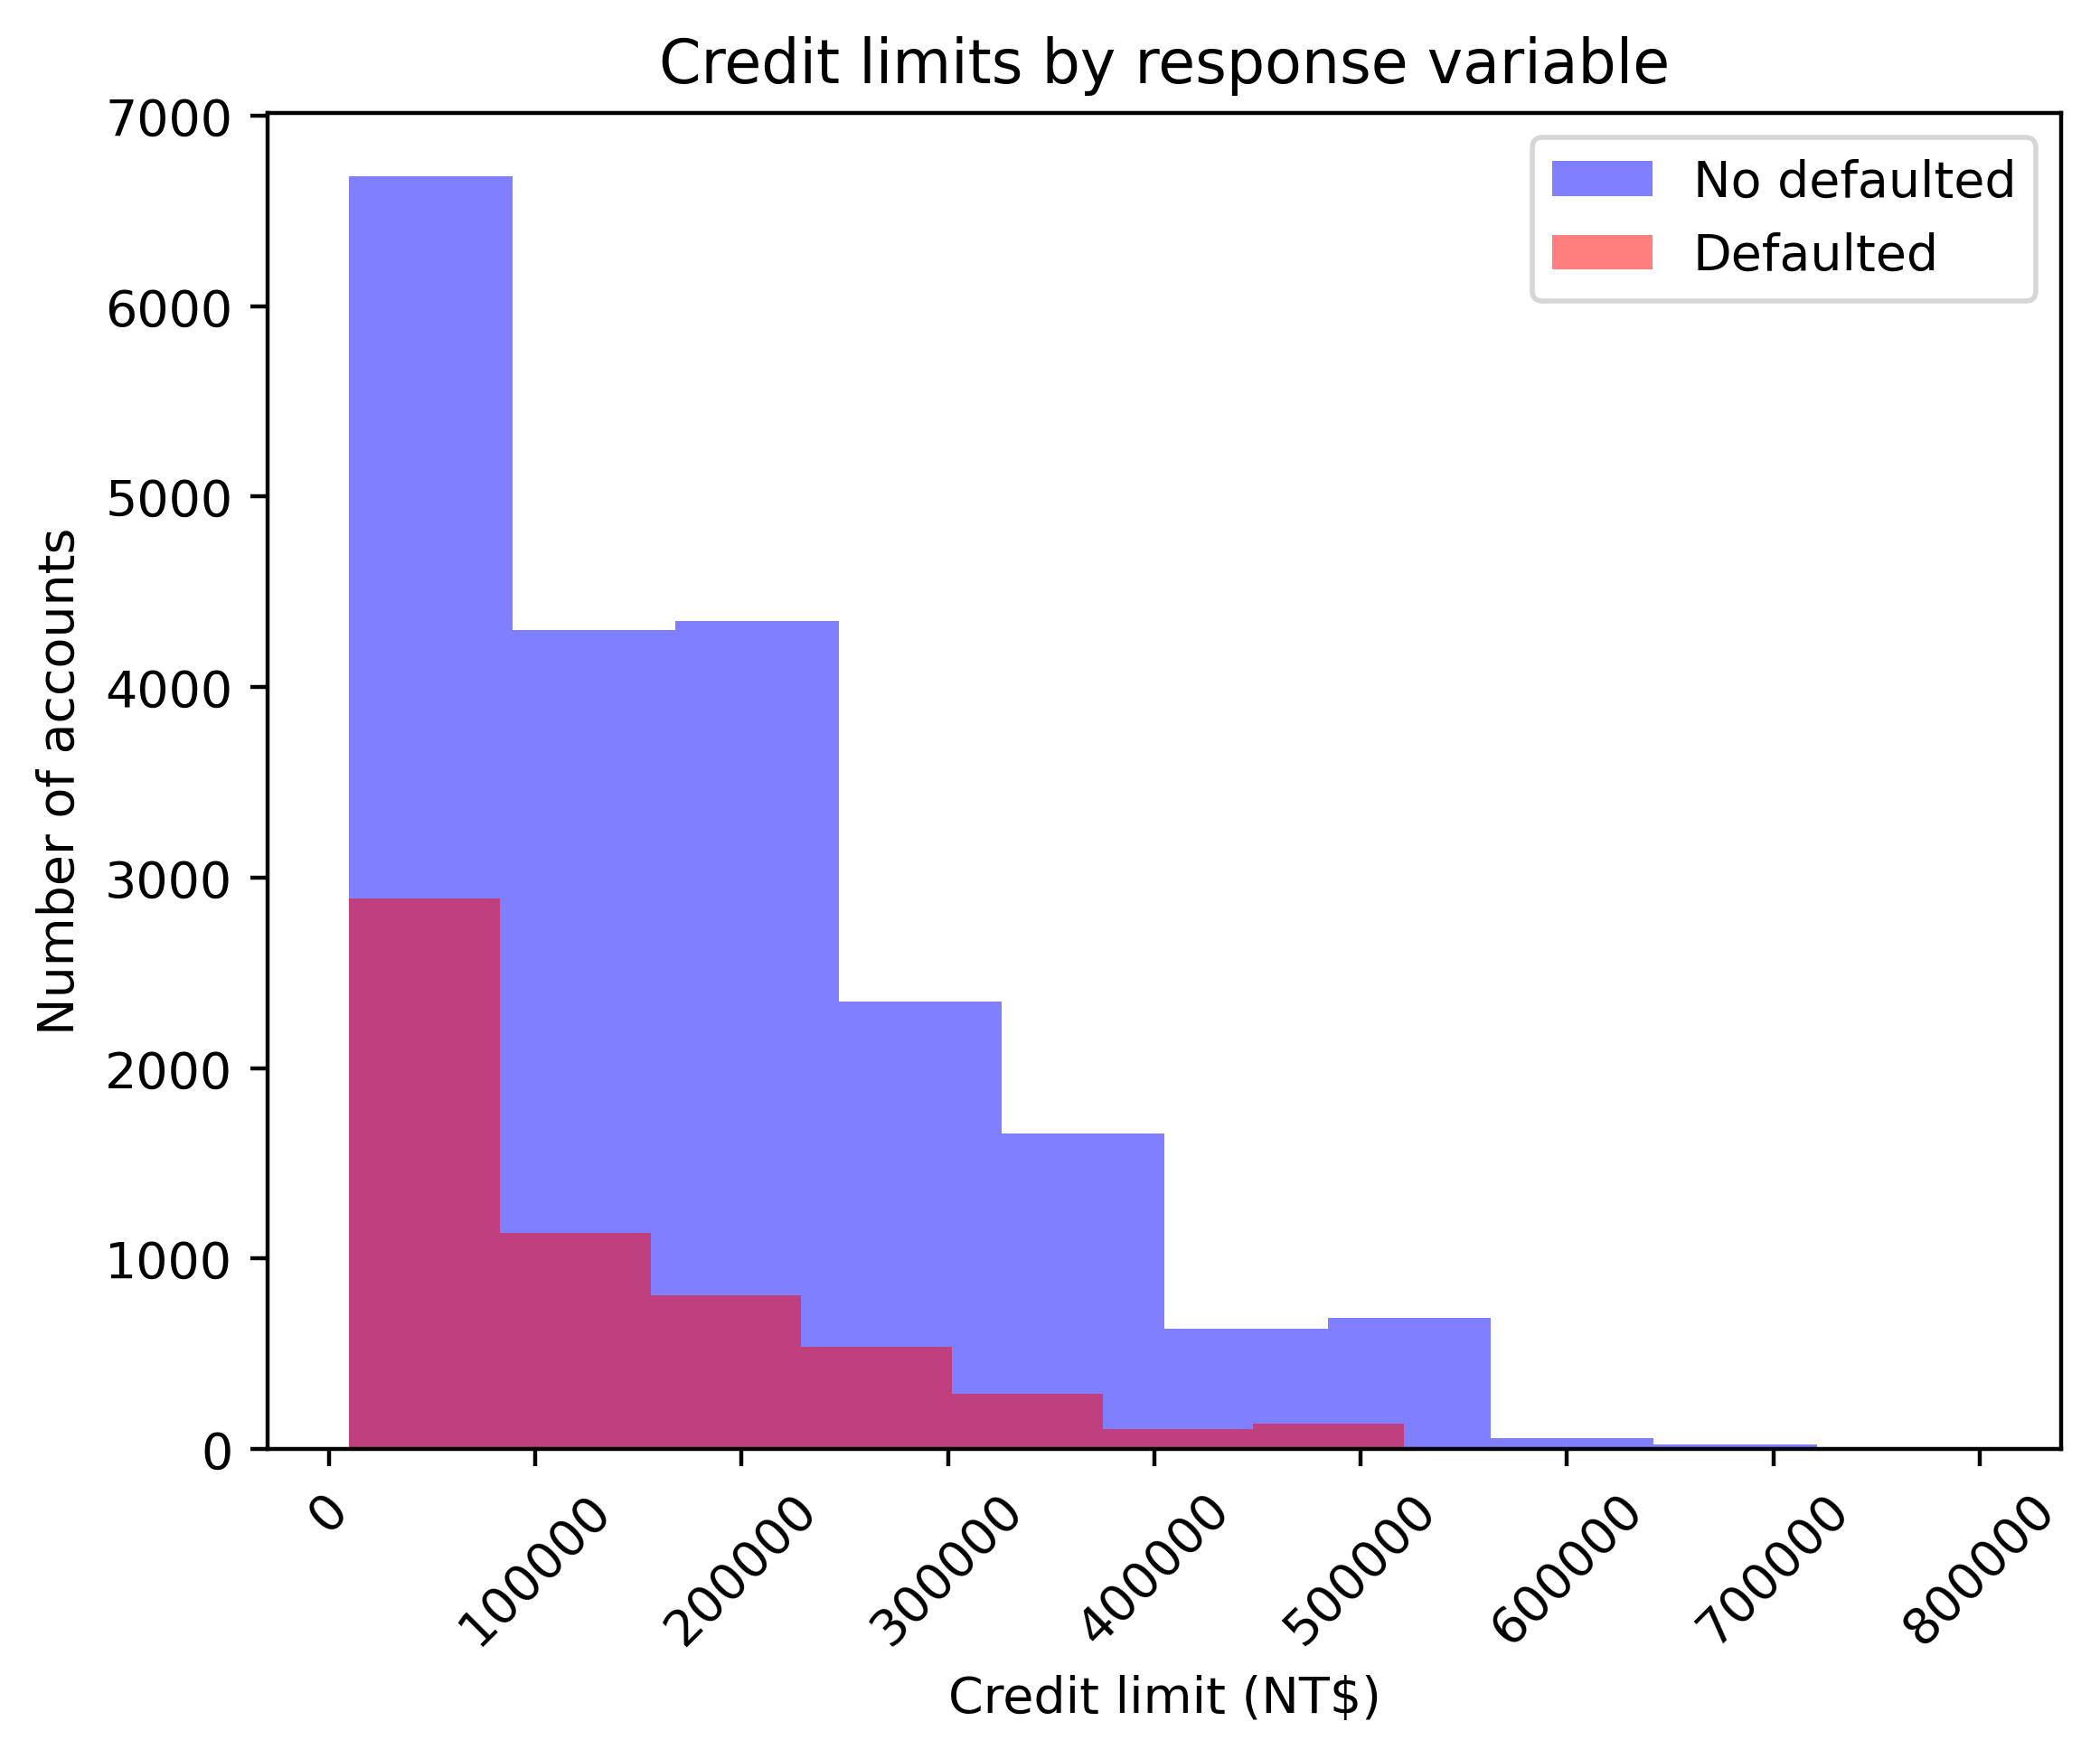

In [18]:
pos_mask = y == 1
neg_mask = y == 0
axes = plt.axes()
axes.hist(df.loc[neg_mask, 'LIMIT_BAL'], color='blue', alpha=0.5)
axes.hist(df.loc[pos_mask, 'LIMIT_BAL'], color='red', alpha=0.5)
axes.tick_params(axis='x', labelrotation=45)
axes.set_xlabel('Credit limit (NT$)')
axes.set_ylabel('Number of accounts')
axes.legend(['No defaulted', 'Defaulted'])
axes.set_title('Credit limits by response variable')

In [19]:
df['LIMIT_BAL'].max()

np.int64(800000)

In [20]:
bin_edges = list(range(0, 850000, 50000))
print(bin_edges[-1])

800000


/tmp/ipykernel_2809/119407219.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_yticklabels(np.round(y_ticks*50000, 2))


Text(0.5, 1.0, 'Normalized distribution of credit limits by response variable')

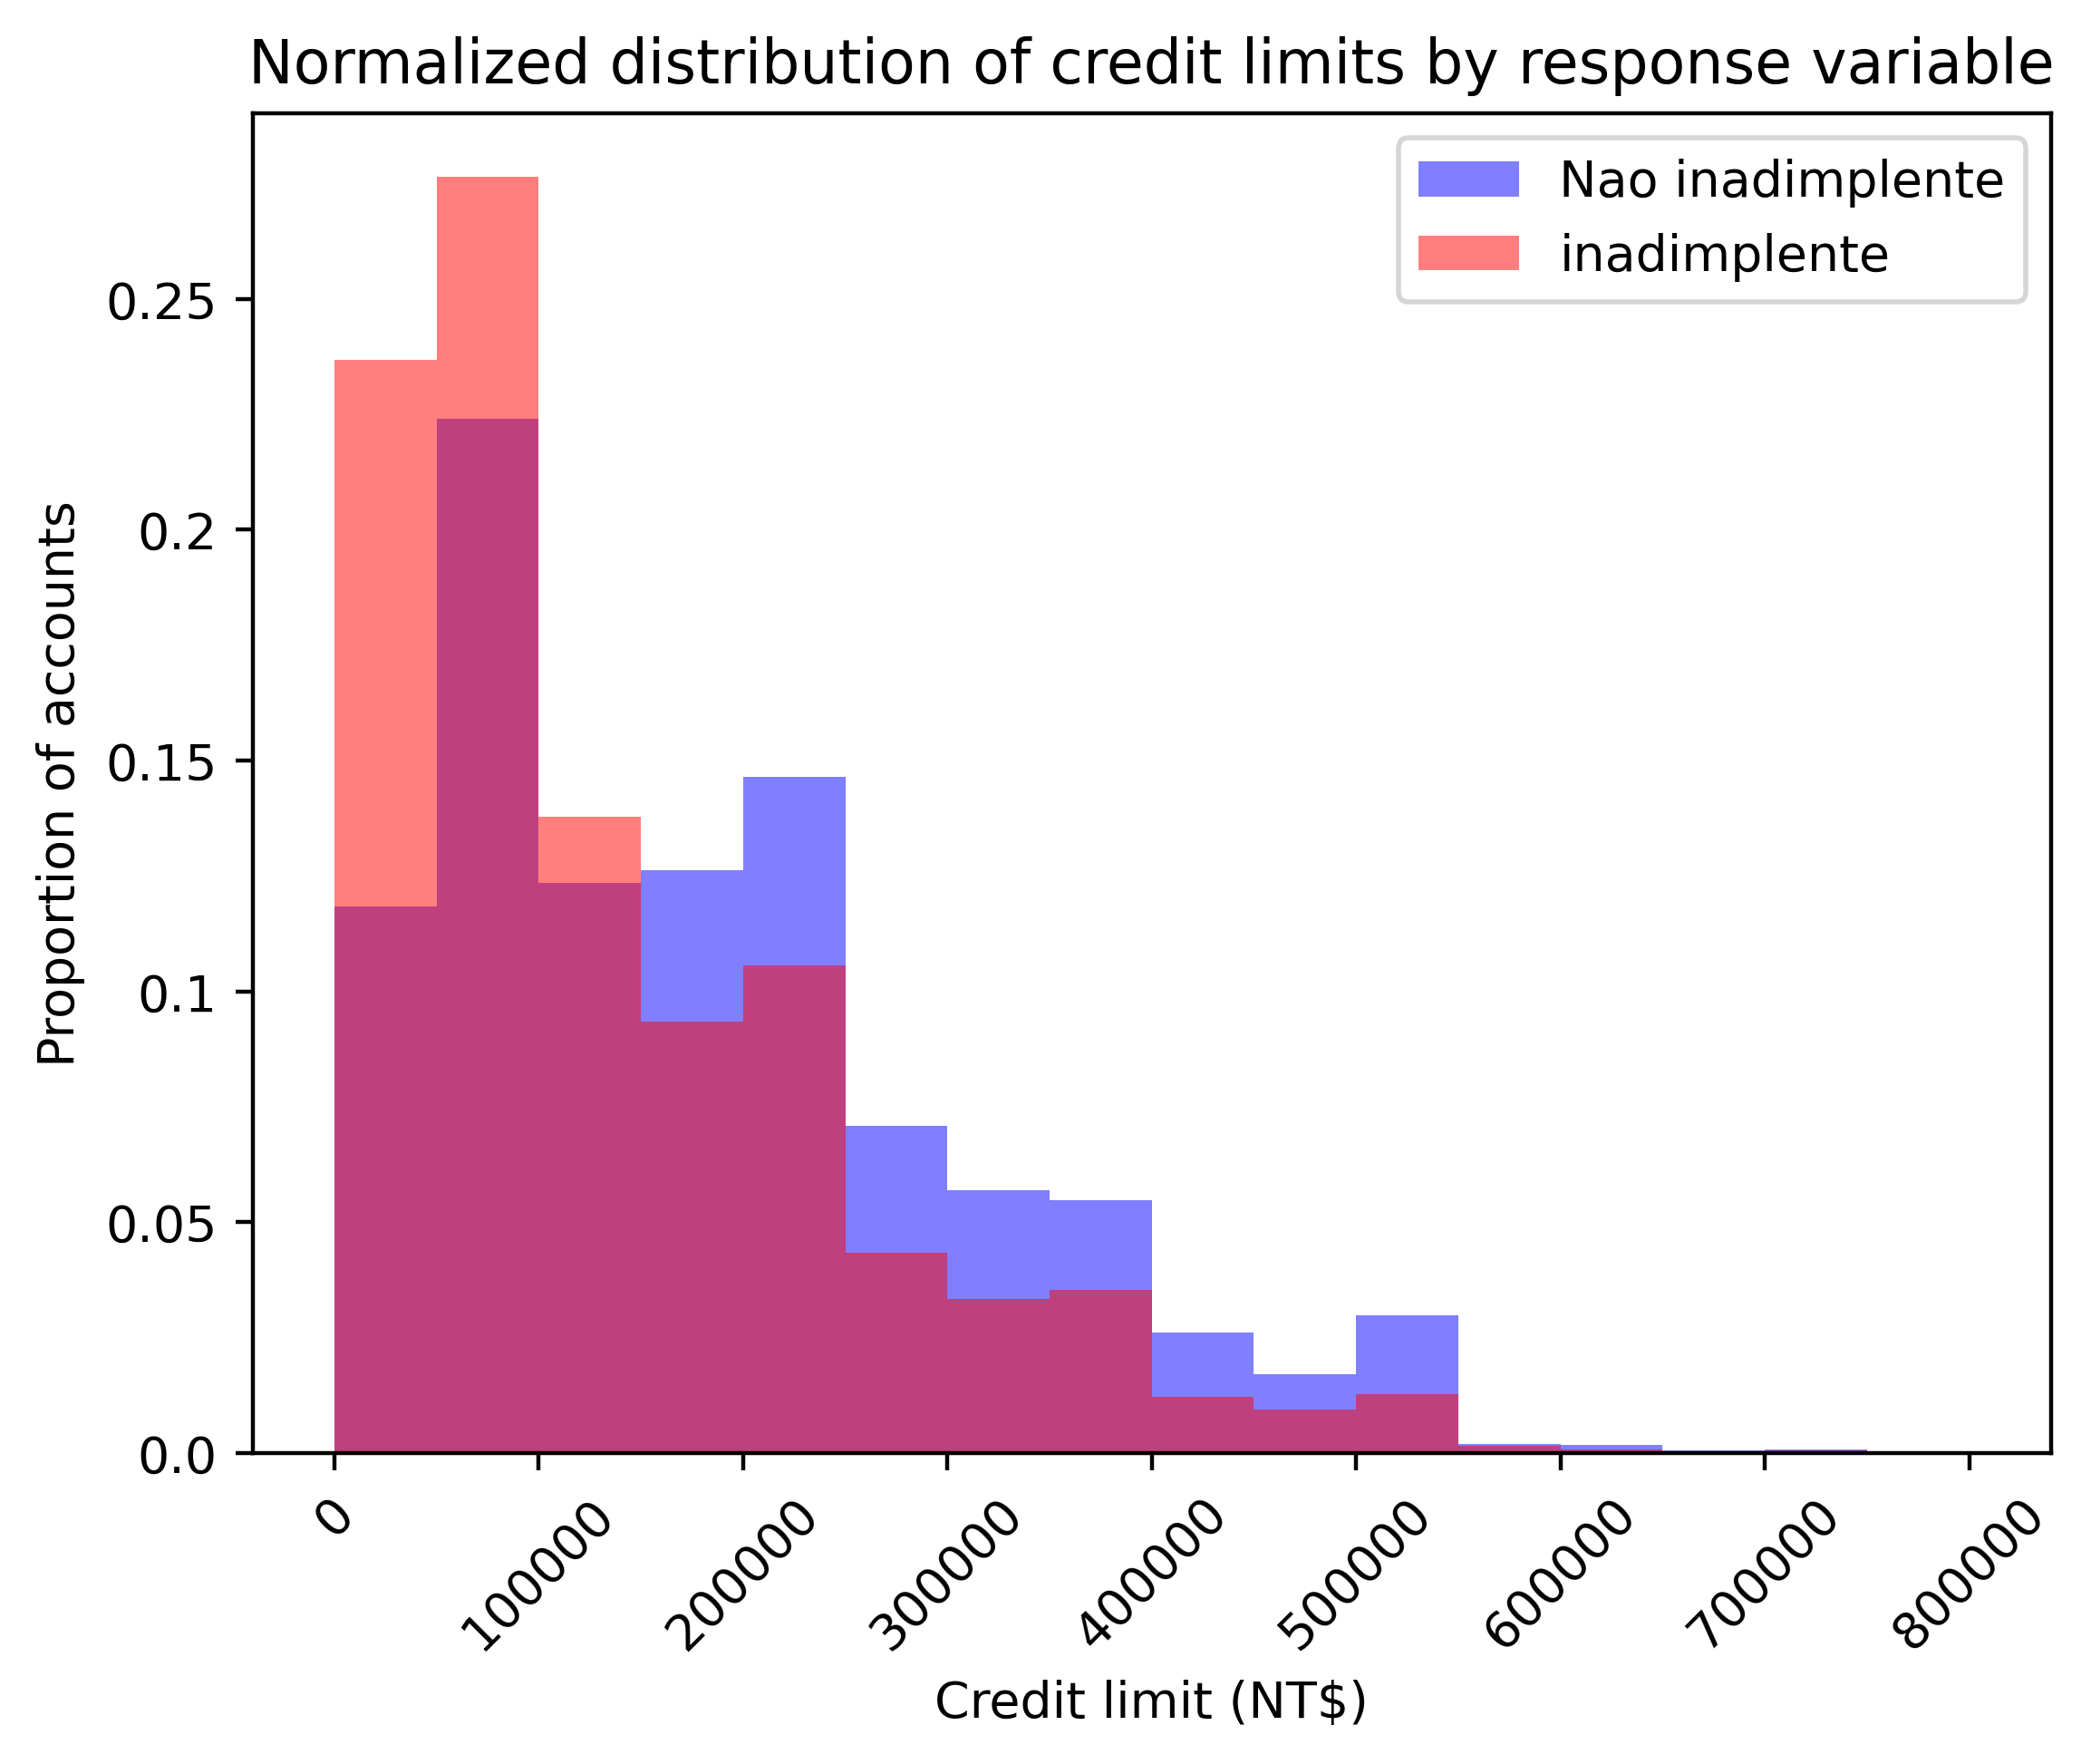

In [21]:
mpl.rcParams['figure.dpi'] = 400
axes = plt.axes()
axes.hist(df.loc[neg_mask, 'LIMIT_BAL'], bins=bin_edges, color='blue', alpha=0.5, density=True)
axes.hist(df.loc[pos_mask, 'LIMIT_BAL'], bins=bin_edges, color='red', alpha=0.5, density=True)
axes.tick_params(axis='x', labelrotation=45)
axes.set_xlabel('Credit limit (NT$)')
axes.set_ylabel('Proportion of accounts')

y_ticks = axes.get_yticks()
axes.set_yticklabels(np.round(y_ticks*50000, 2))
axes.legend(['Nao inadimplente', 'inadimplente'])
axes.set_title('Normalized distribution of credit limits by response variable')


In [22]:
X_exp = np.linspace(-4, 4, 81)
print(X_exp)

[-4.  -3.9 -3.8 -3.7 -3.6 -3.5 -3.4 -3.3 -3.2 -3.1 -3.  -2.9 -2.8 -2.7
 -2.6 -2.5 -2.4 -2.3 -2.2 -2.1 -2.  -1.9 -1.8 -1.7 -1.6 -1.5 -1.4 -1.3
 -1.2 -1.1 -1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1
  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3  1.4  1.5
  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7  2.8  2.9
  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4. ]


In [23]:
X_exp.shape

(81,)

In [24]:
Y_exp = np.exp(X_exp)
Y_exp[:5]

array([0.01831564, 0.02024191, 0.02237077, 0.02472353, 0.02732372])

Text(0.5, 1.0, 'Plot of $e^x$')

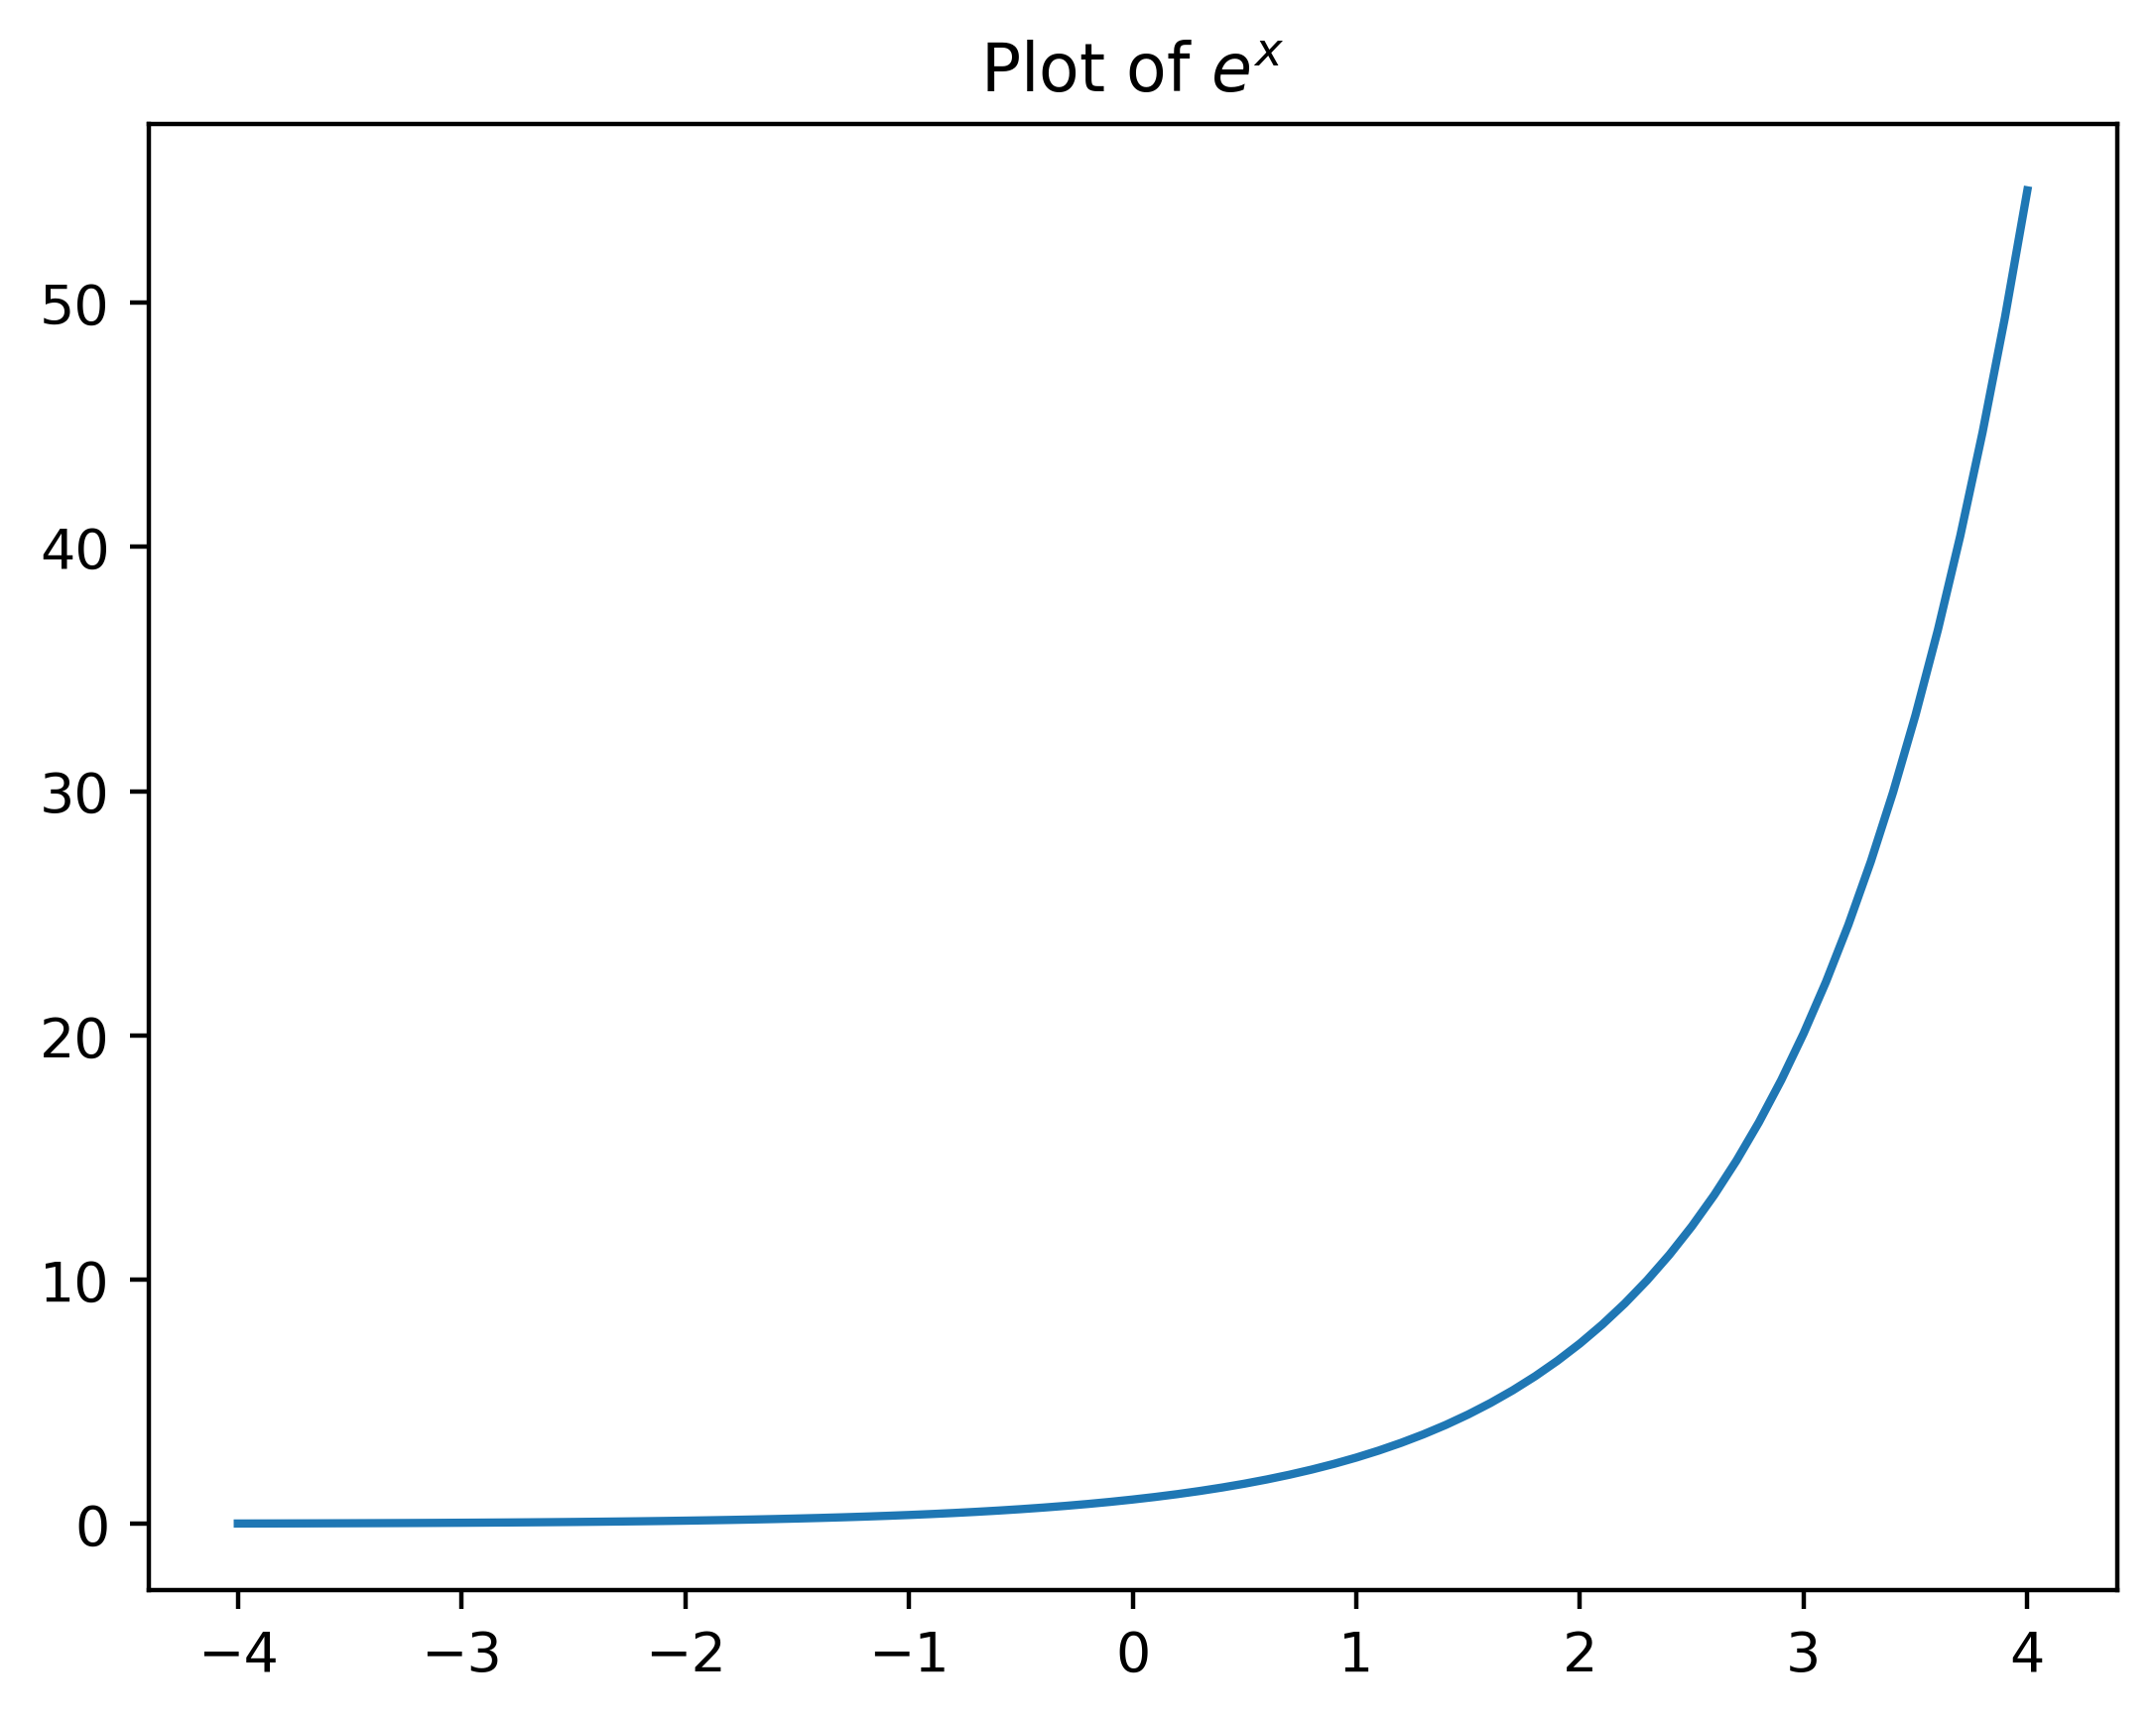

In [25]:
#plotando a função sigmóide
plt.plot(X_exp, Y_exp)
plt.title('Plot of $e^x$')

Text(0.5, 1.0, 'Plot of $e^{-x}$')

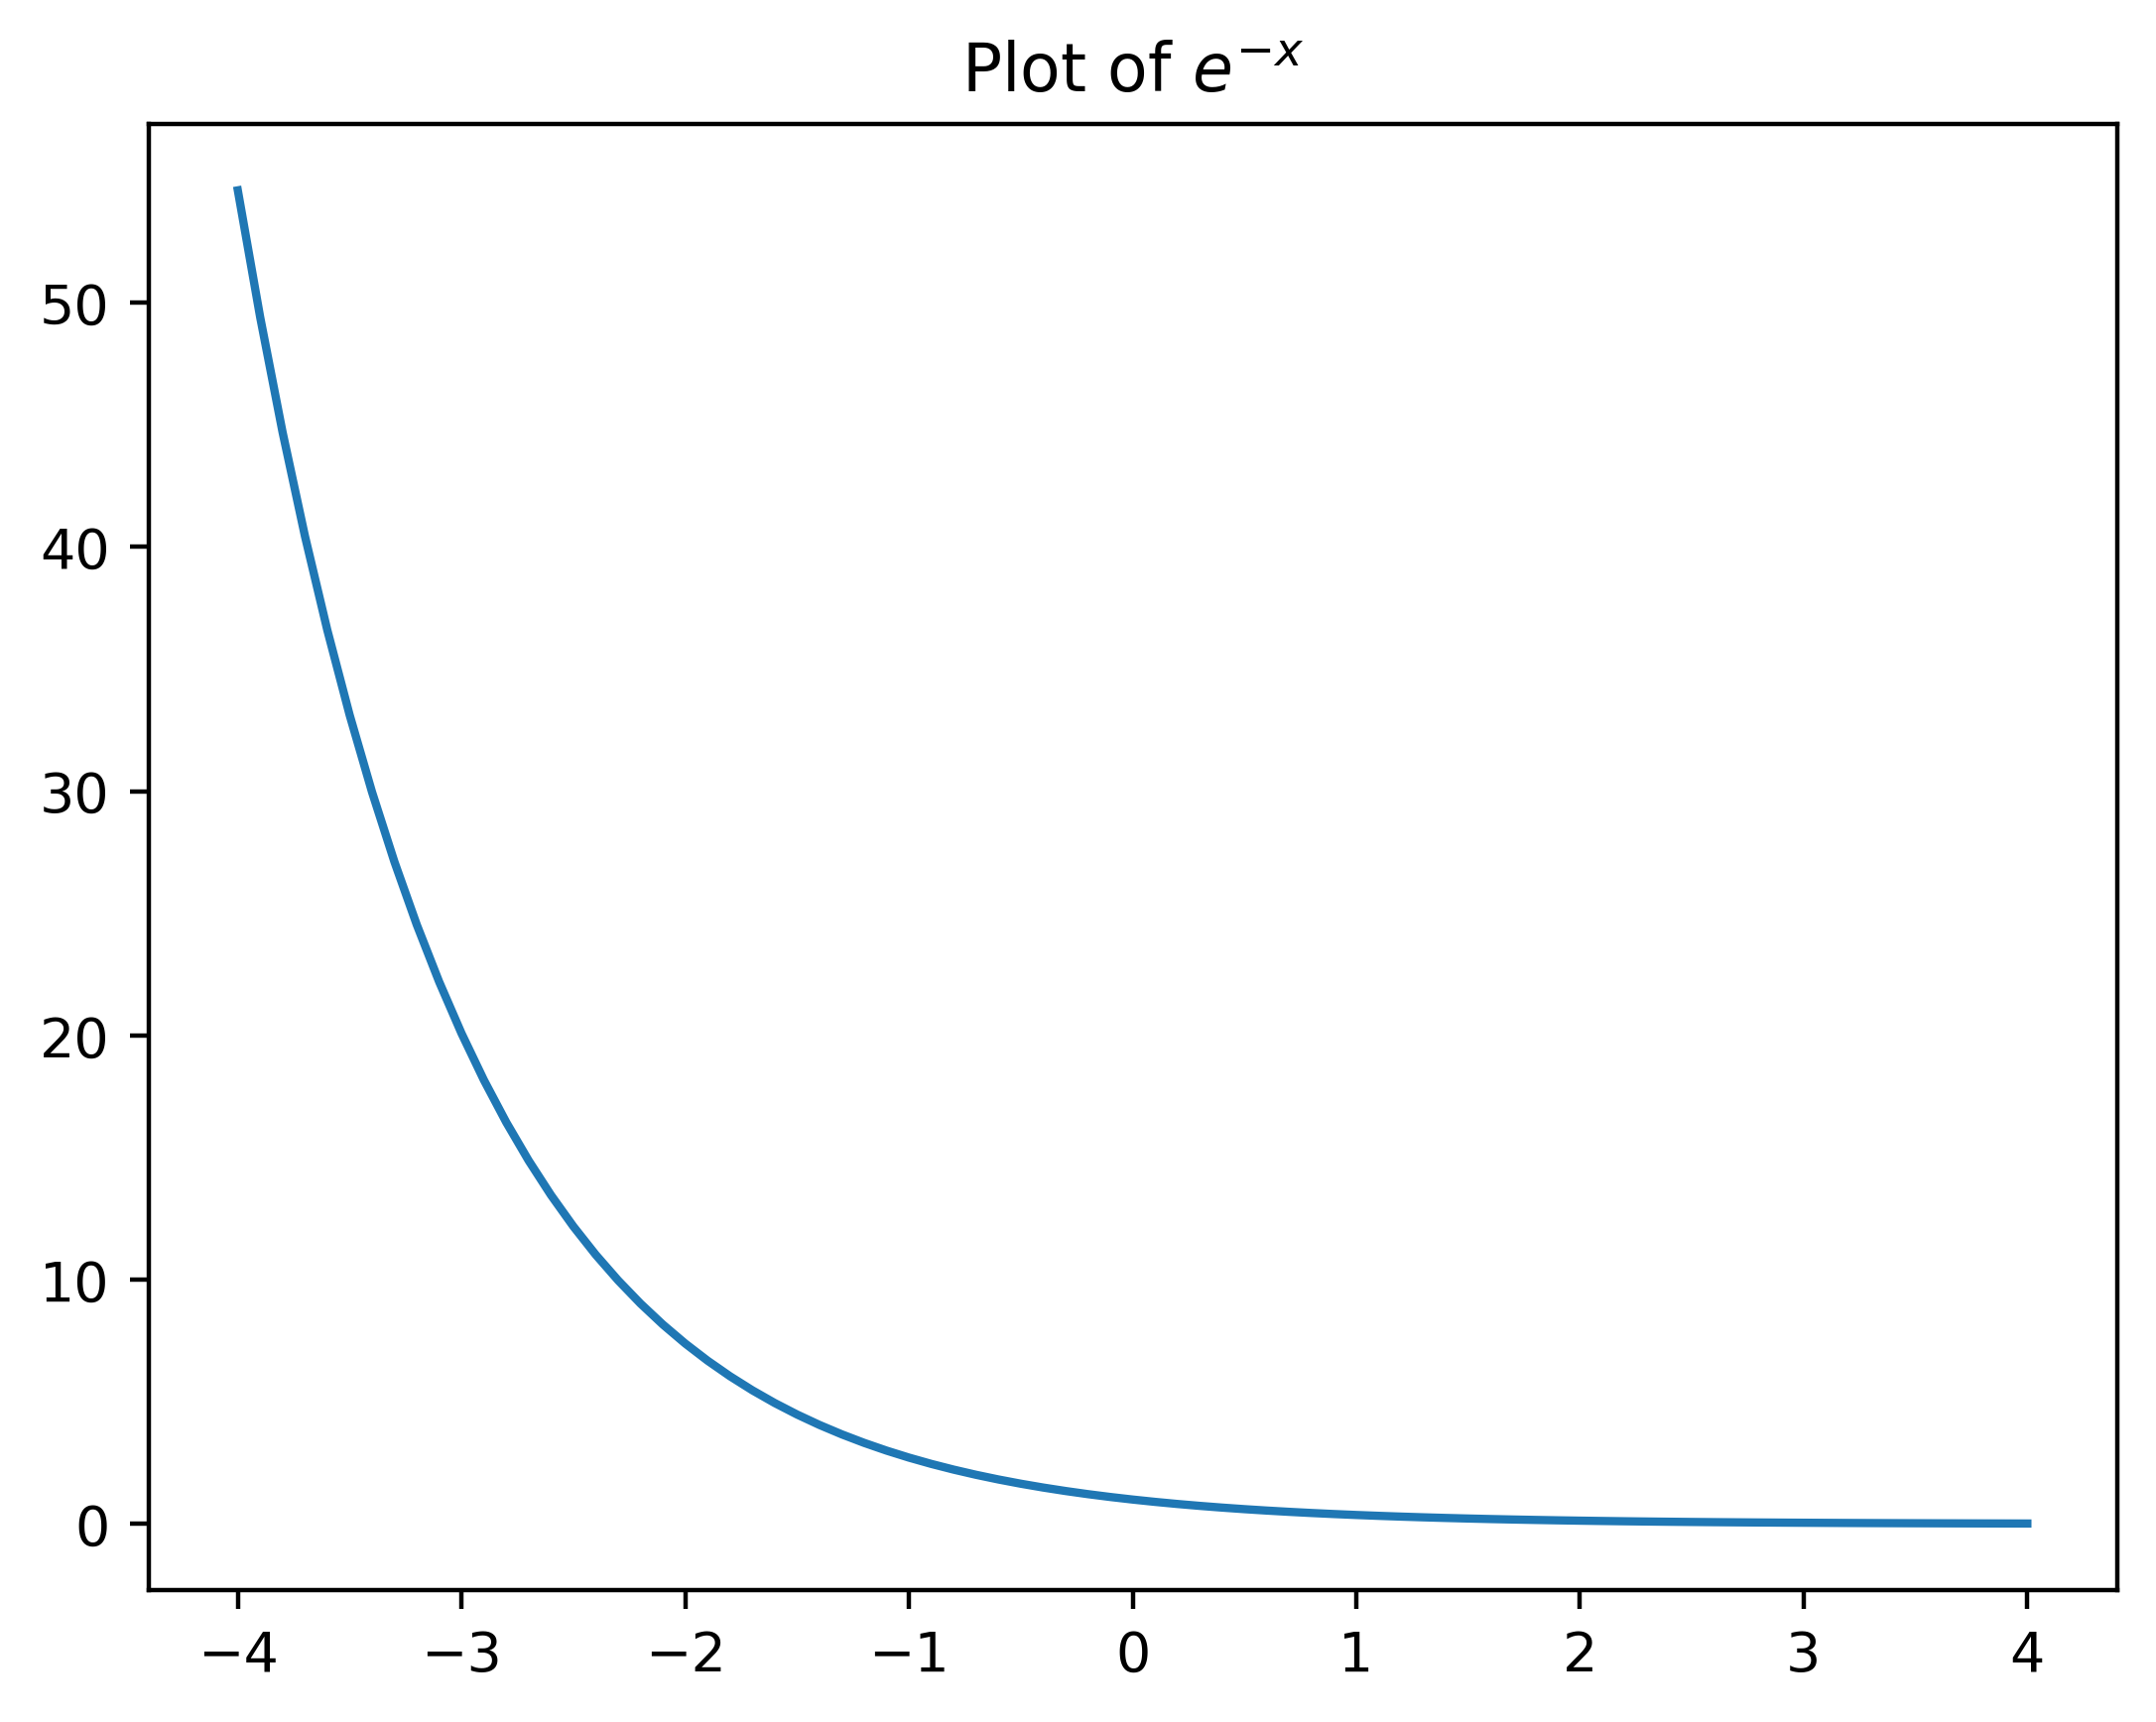

In [26]:
Y_exp = np.exp(-X_exp)
plt.plot(X_exp, Y_exp)
plt.title('Plot of $e^{-x}$')

Text(0.5, 1.0, 'The Sigmoid Function')

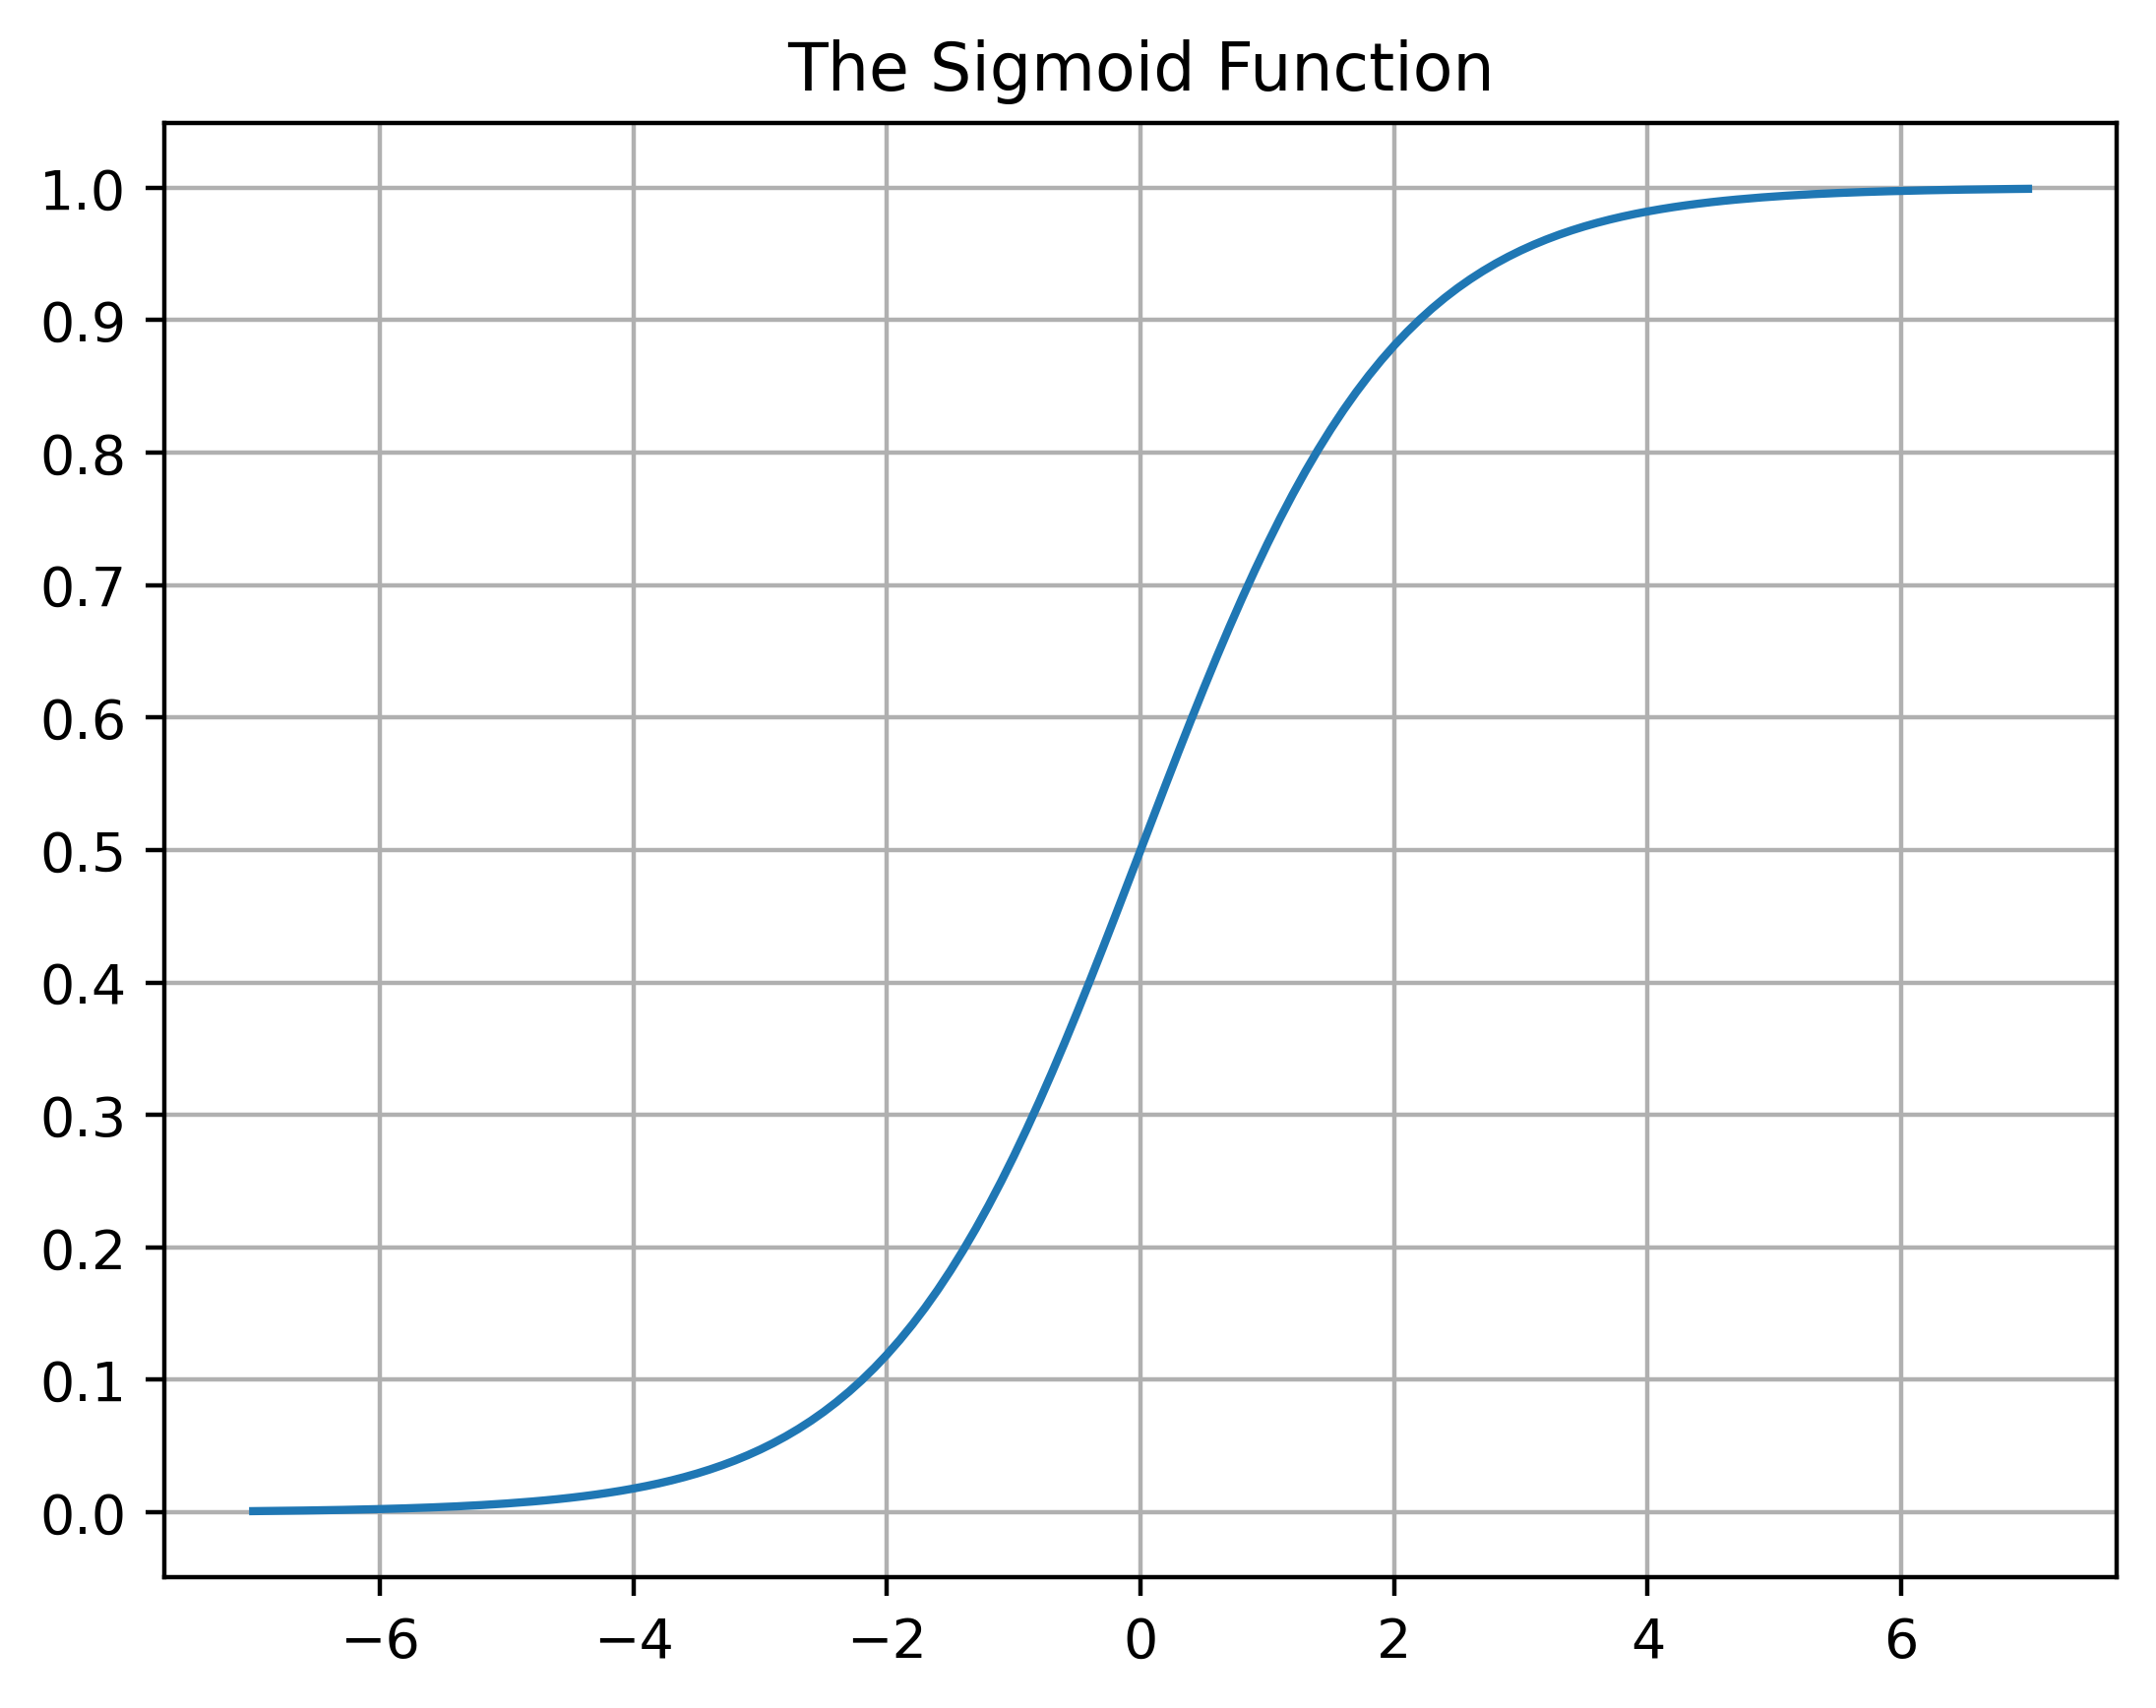

In [27]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

X_sig = np.linspace(-7, 7, 141)
Y_sig = sigmoid(X_sig)
plt.plot(X_sig, Y_sig)
plt.yticks(np.linspace(0, 1, 11))
plt.grid()
plt.title('The Sigmoid Function')

In [28]:
group_by_pay_mean_y

,default payment next month
PAY_1,
-2,0.131664
-1,0.170002
0,0.128295
1,0.336400
2,0.694701
3,0.773973
4,0.682540
5,0.434783
6,0.545455


In [29]:
p = group_by_pay_mean_y['default payment next month'].values
q = 1-p
print(p)
print(q)

[0.13166397 0.17000198 0.12829525 0.33639988 0.69470143 0.7739726
 0.68253968 0.43478261 0.54545455 0.77777778 0.58823529]
[0.86833603 0.82999802 0.87170475 0.66360012 0.30529857 0.2260274
 0.31746032 0.56521739 0.45454545 0.22222222 0.41176471]


In [30]:
#calculando a razao de possibilidades de p e q, assim como o logaritmo das chances, usando a funcao de logaritmo natural do numpy
odds_ratio = p/q
log_odds = np.log(odds_ratio)
log_odds

array([-1.88632574, -1.58561322, -1.91611649, -0.67937918,  0.82219194,
        1.23088026,  0.76546784, -0.26236426,  0.18232156,  1.25276297,
        0.35667494])

In [31]:
group_by_pay_mean_y.index

Index([-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8], dtype='int64', name='PAY_1')

Text(0.5, 0, 'PAY_1 values')

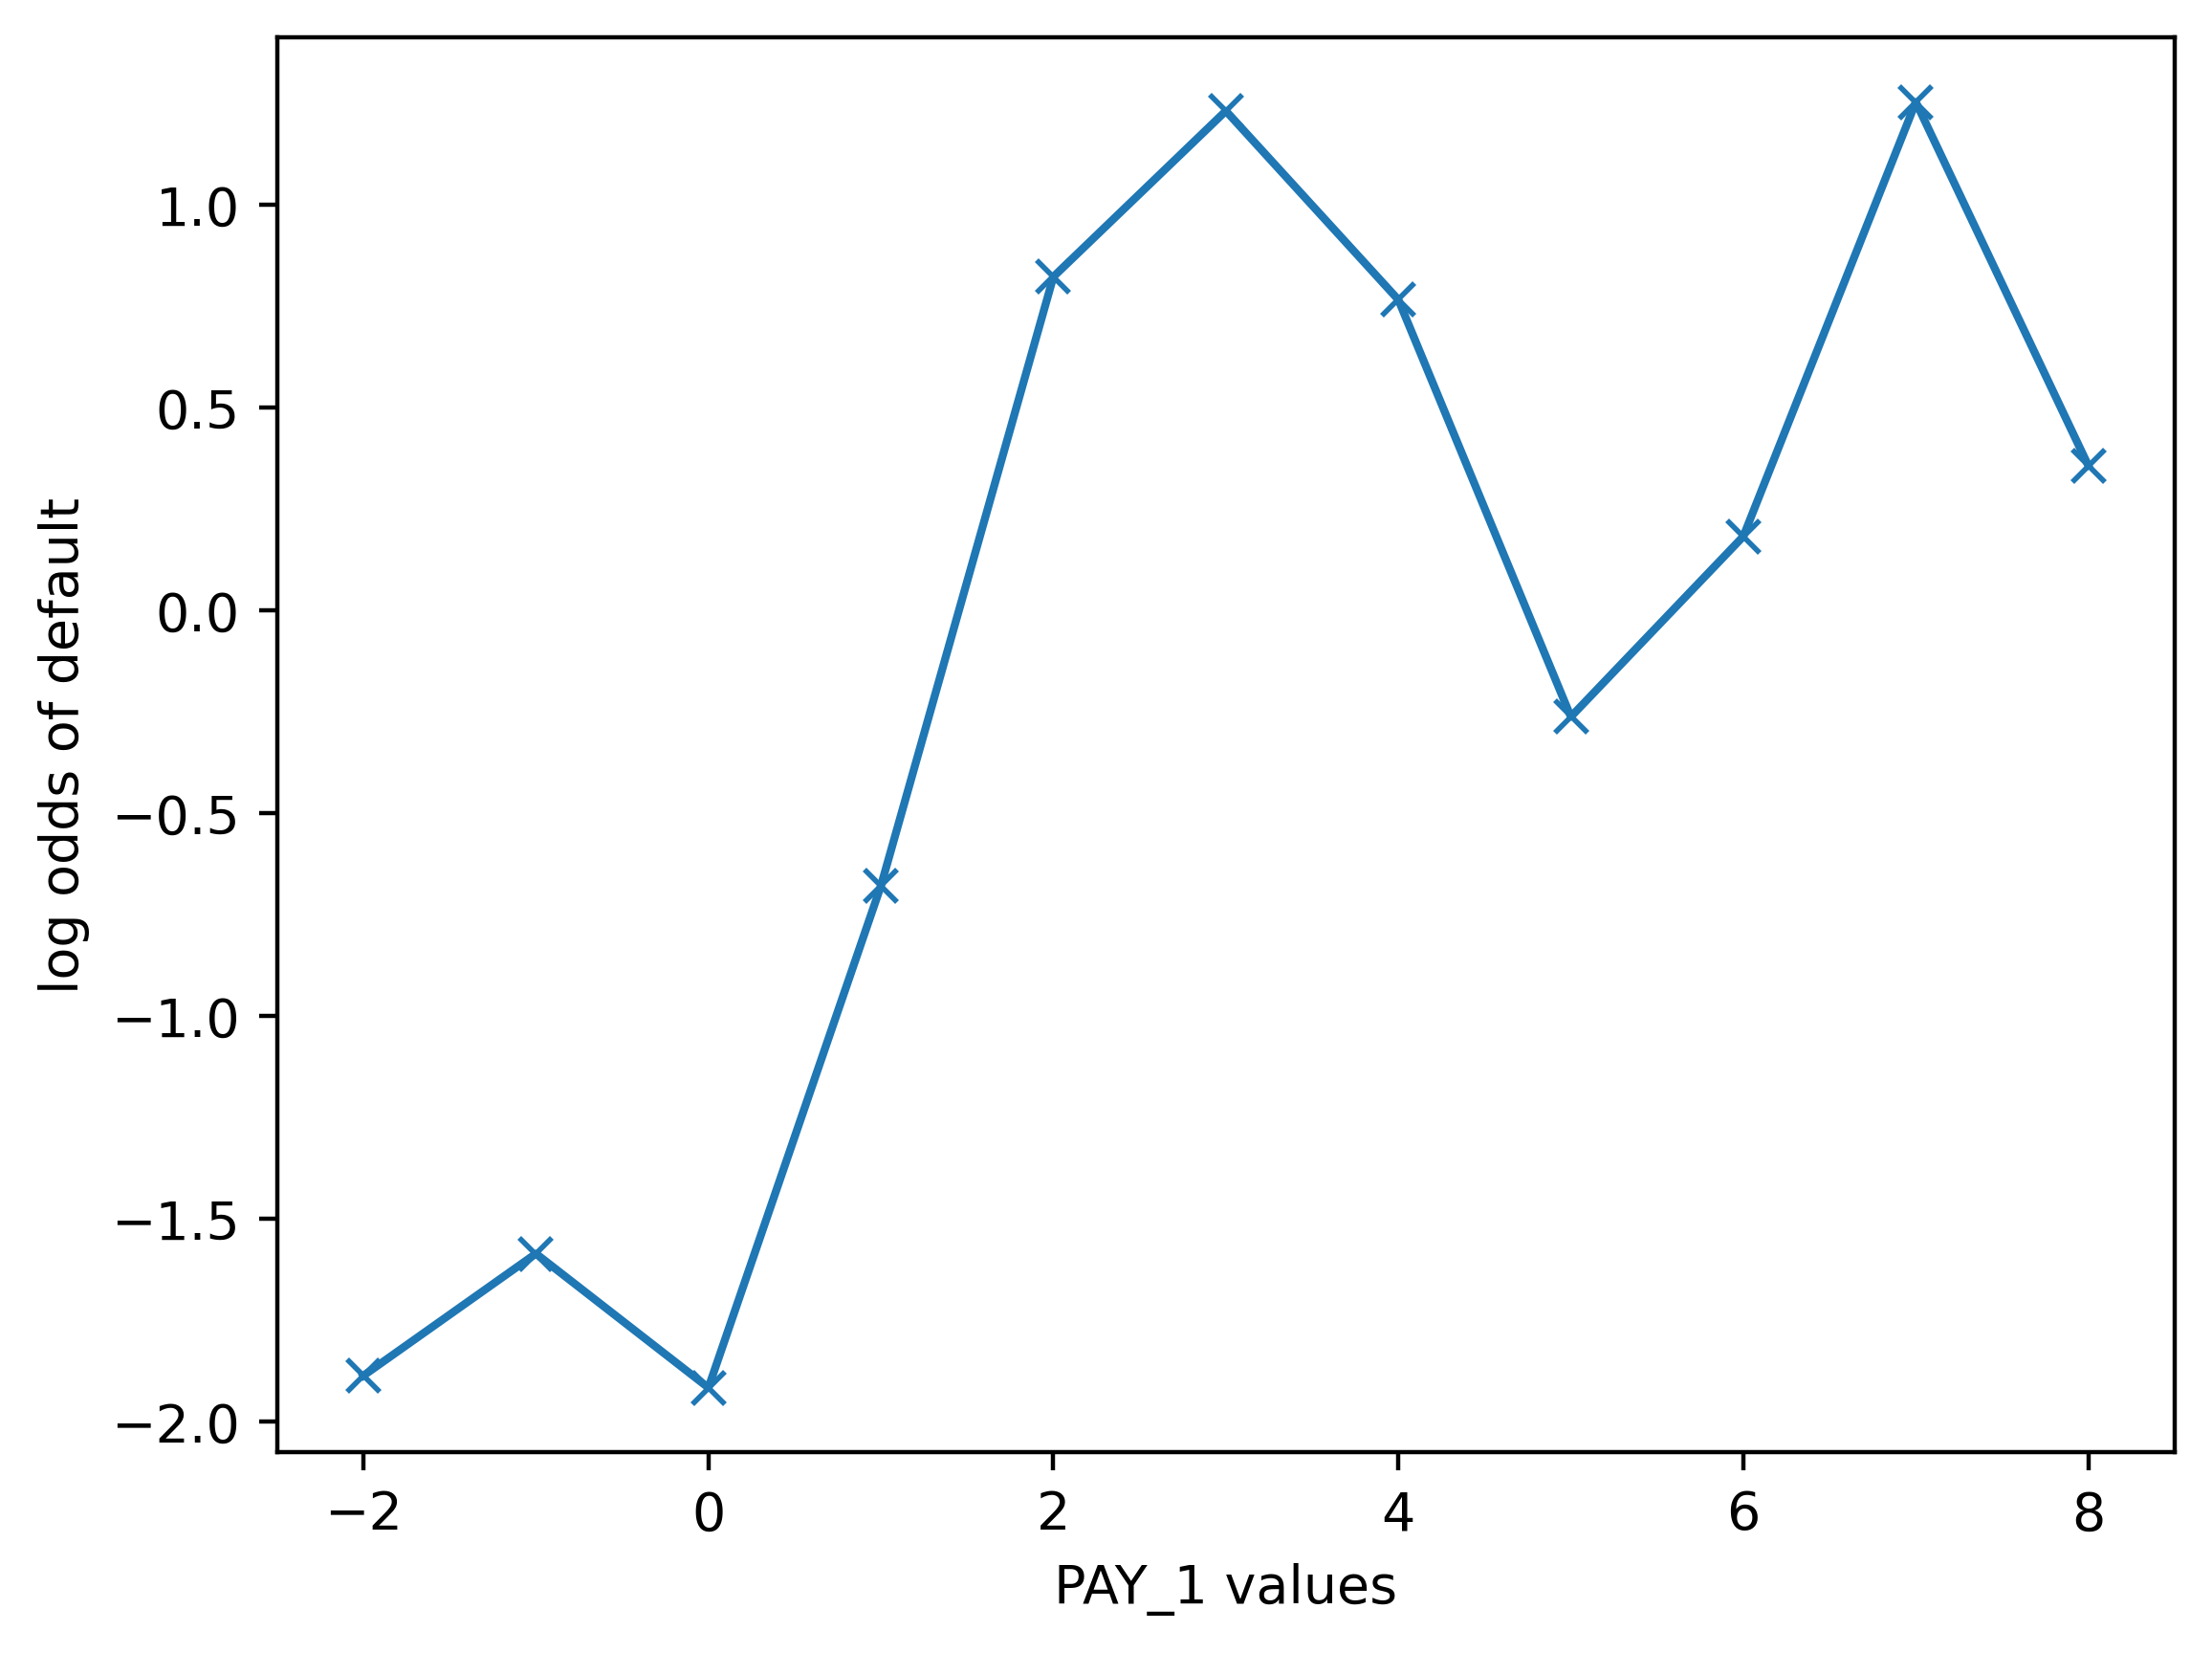

In [34]:
#plotagem que exibe o logaritmo das chances dos valores da característica PAY_1
plt.plot(group_by_pay_mean_y.index, log_odds, '-x')
plt.ylabel('log odds of default')
plt.xlabel('PAY_1 values')

In [37]:
np.random.seed(seed=6)
X_1_pos = np.random.uniform(low=1, high=7, size=(20,1))
print(X_1_pos[0:3])
X_1_neg = np.random.uniform(low=3, high=10, size=(20,1))
print(X_1_neg[0:3])
X_2_pos = np.random.uniform(low=1, high=7, size=(20,1))
print(X_2_pos[0:3])
X_2_neg = np.random.uniform(low=3, high=10, size=(20,1))
print(X_2_neg[0:3])

[[6.35716091]
 [2.99187883]
 [5.92737474]]
[[3.38132155]
 [8.03046066]
 [8.61519394]]
[[5.4790643 ]
 [5.3444234 ]
 [3.43664678]]
[[9.19684856]
 [9.83587114]
 [8.85836015]]


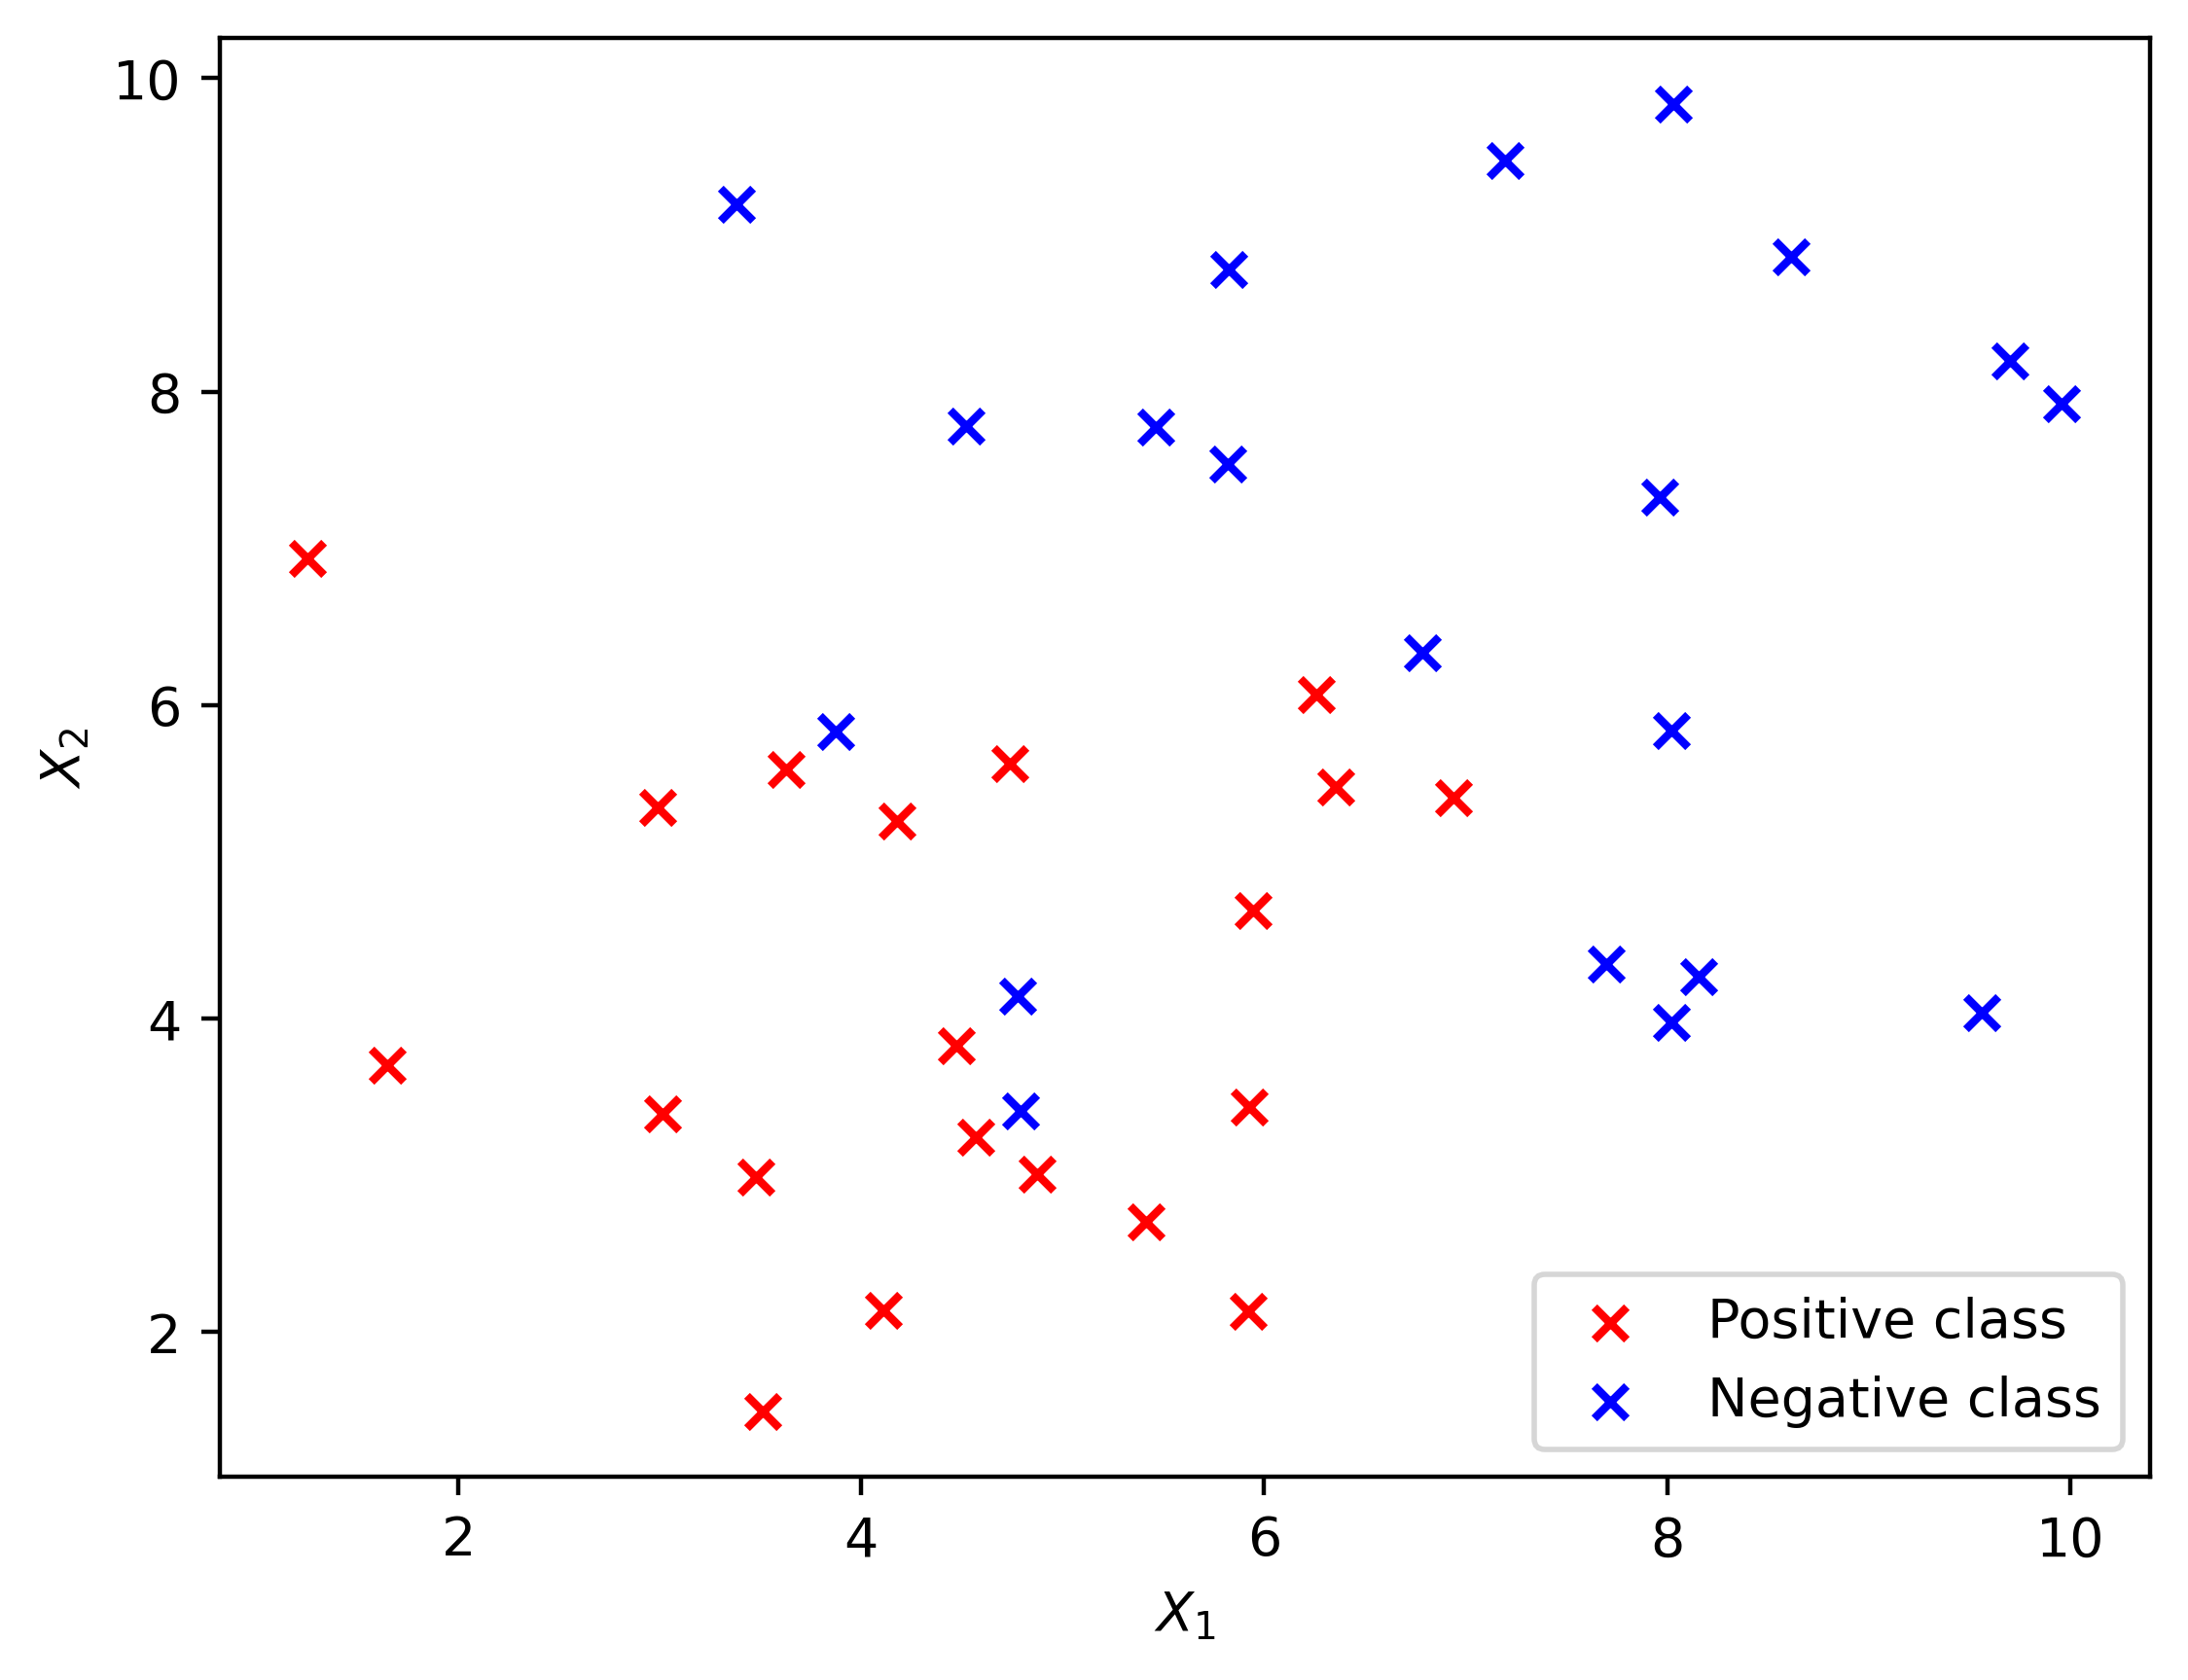

In [38]:
plt.scatter(X_1_pos, X_2_pos, color='red', marker='x')
plt.scatter(X_1_neg, X_2_neg, color='blue', marker='x')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend(['Positive class', 'Negative class'])

In [39]:
X = np.block([[X_1_pos, X_2_pos], [X_1_neg, X_2_neg]])
print(X.shape)
print(X[0:3])

(40, 2)
[[6.35716091 5.4790643 ]
 [2.99187883 5.3444234 ]
 [5.92737474 3.43664678]]


In [40]:
y = np.vstack((np.ones((20, 1)), np.zeros((20, 1)))).reshape(40,)
print(y[0:5])
print(y[-5:])

[1. 1. 1. 1. 1.]
[0. 0. 0. 0. 0.]


In [41]:
from sklearn.linear_model import LogisticRegression

example_lr = LogisticRegression(solver='liblinear')
example_lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [42]:
example_lr.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [43]:
y_pred = example_lr.predict(X)
positive_indices = [counter for counter in range(len(y_pred)) if y_pred[counter] == 1]
negative_indices = [counter for counter in range(len(y_pred)) if y_pred[counter] == 0]
positive_indices

[1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, 17, 32, 38]

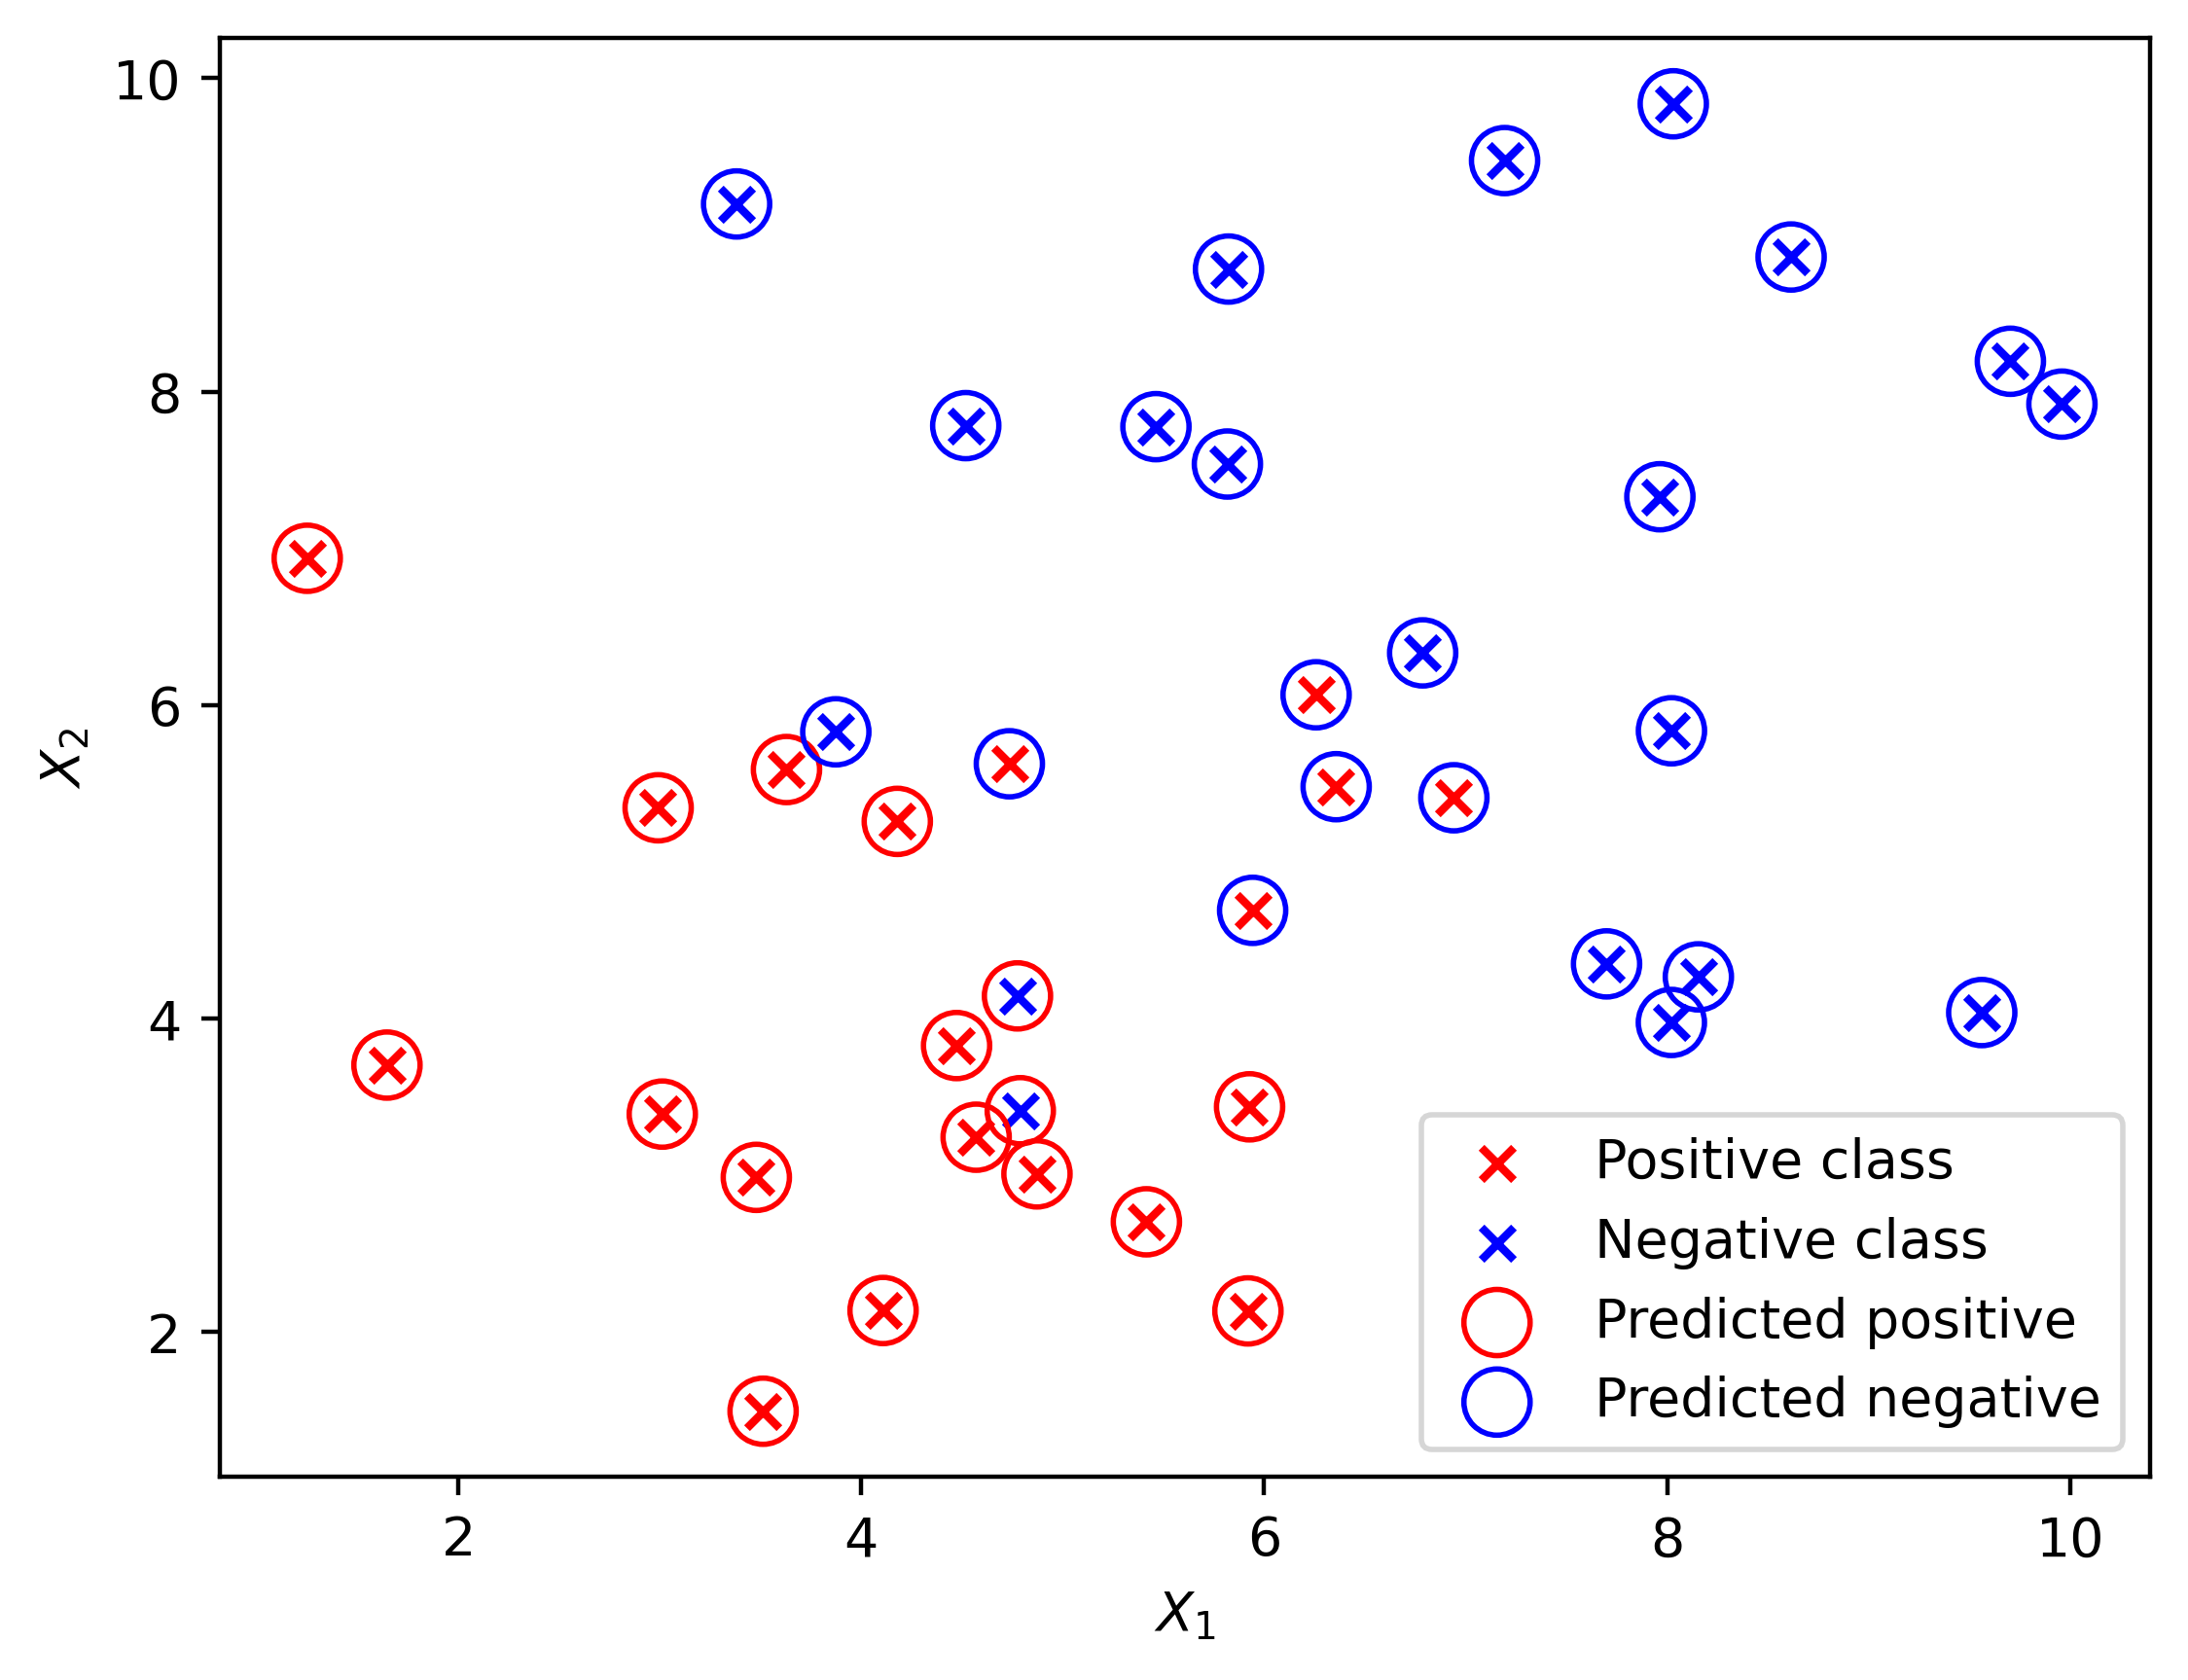

In [44]:
plt.scatter(X_1_pos, X_2_pos, color='red', marker='x')
plt.scatter(X_1_neg, X_2_neg, color='blue', marker='x')
plt.scatter(X[positive_indices, 0], X[positive_indices, 1], facecolors='none', edgecolors='red', s=150, marker='o')
plt.scatter(X[negative_indices, 0], X[negative_indices, 1], facecolors='none', edgecolors='blue', s=150, marker='o')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.legend(['Positive class', 'Negative class', 'Predicted positive', 'Predicted negative'])


In [45]:
theta_1 = example_lr.coef_[0][0]
theta_2 = example_lr.coef_[0][1]

print(theta_1, theta_2)

-0.20245058016285838 -0.25336423626773225


In [46]:
theta_0 = example_lr.intercept_

In [47]:
X_1_decision_boundary = np.array([0, 10])
X_2_decision_boundary = -(theta_1/theta_2)*X_1_decision_boundary - (theta_0/theta_2)

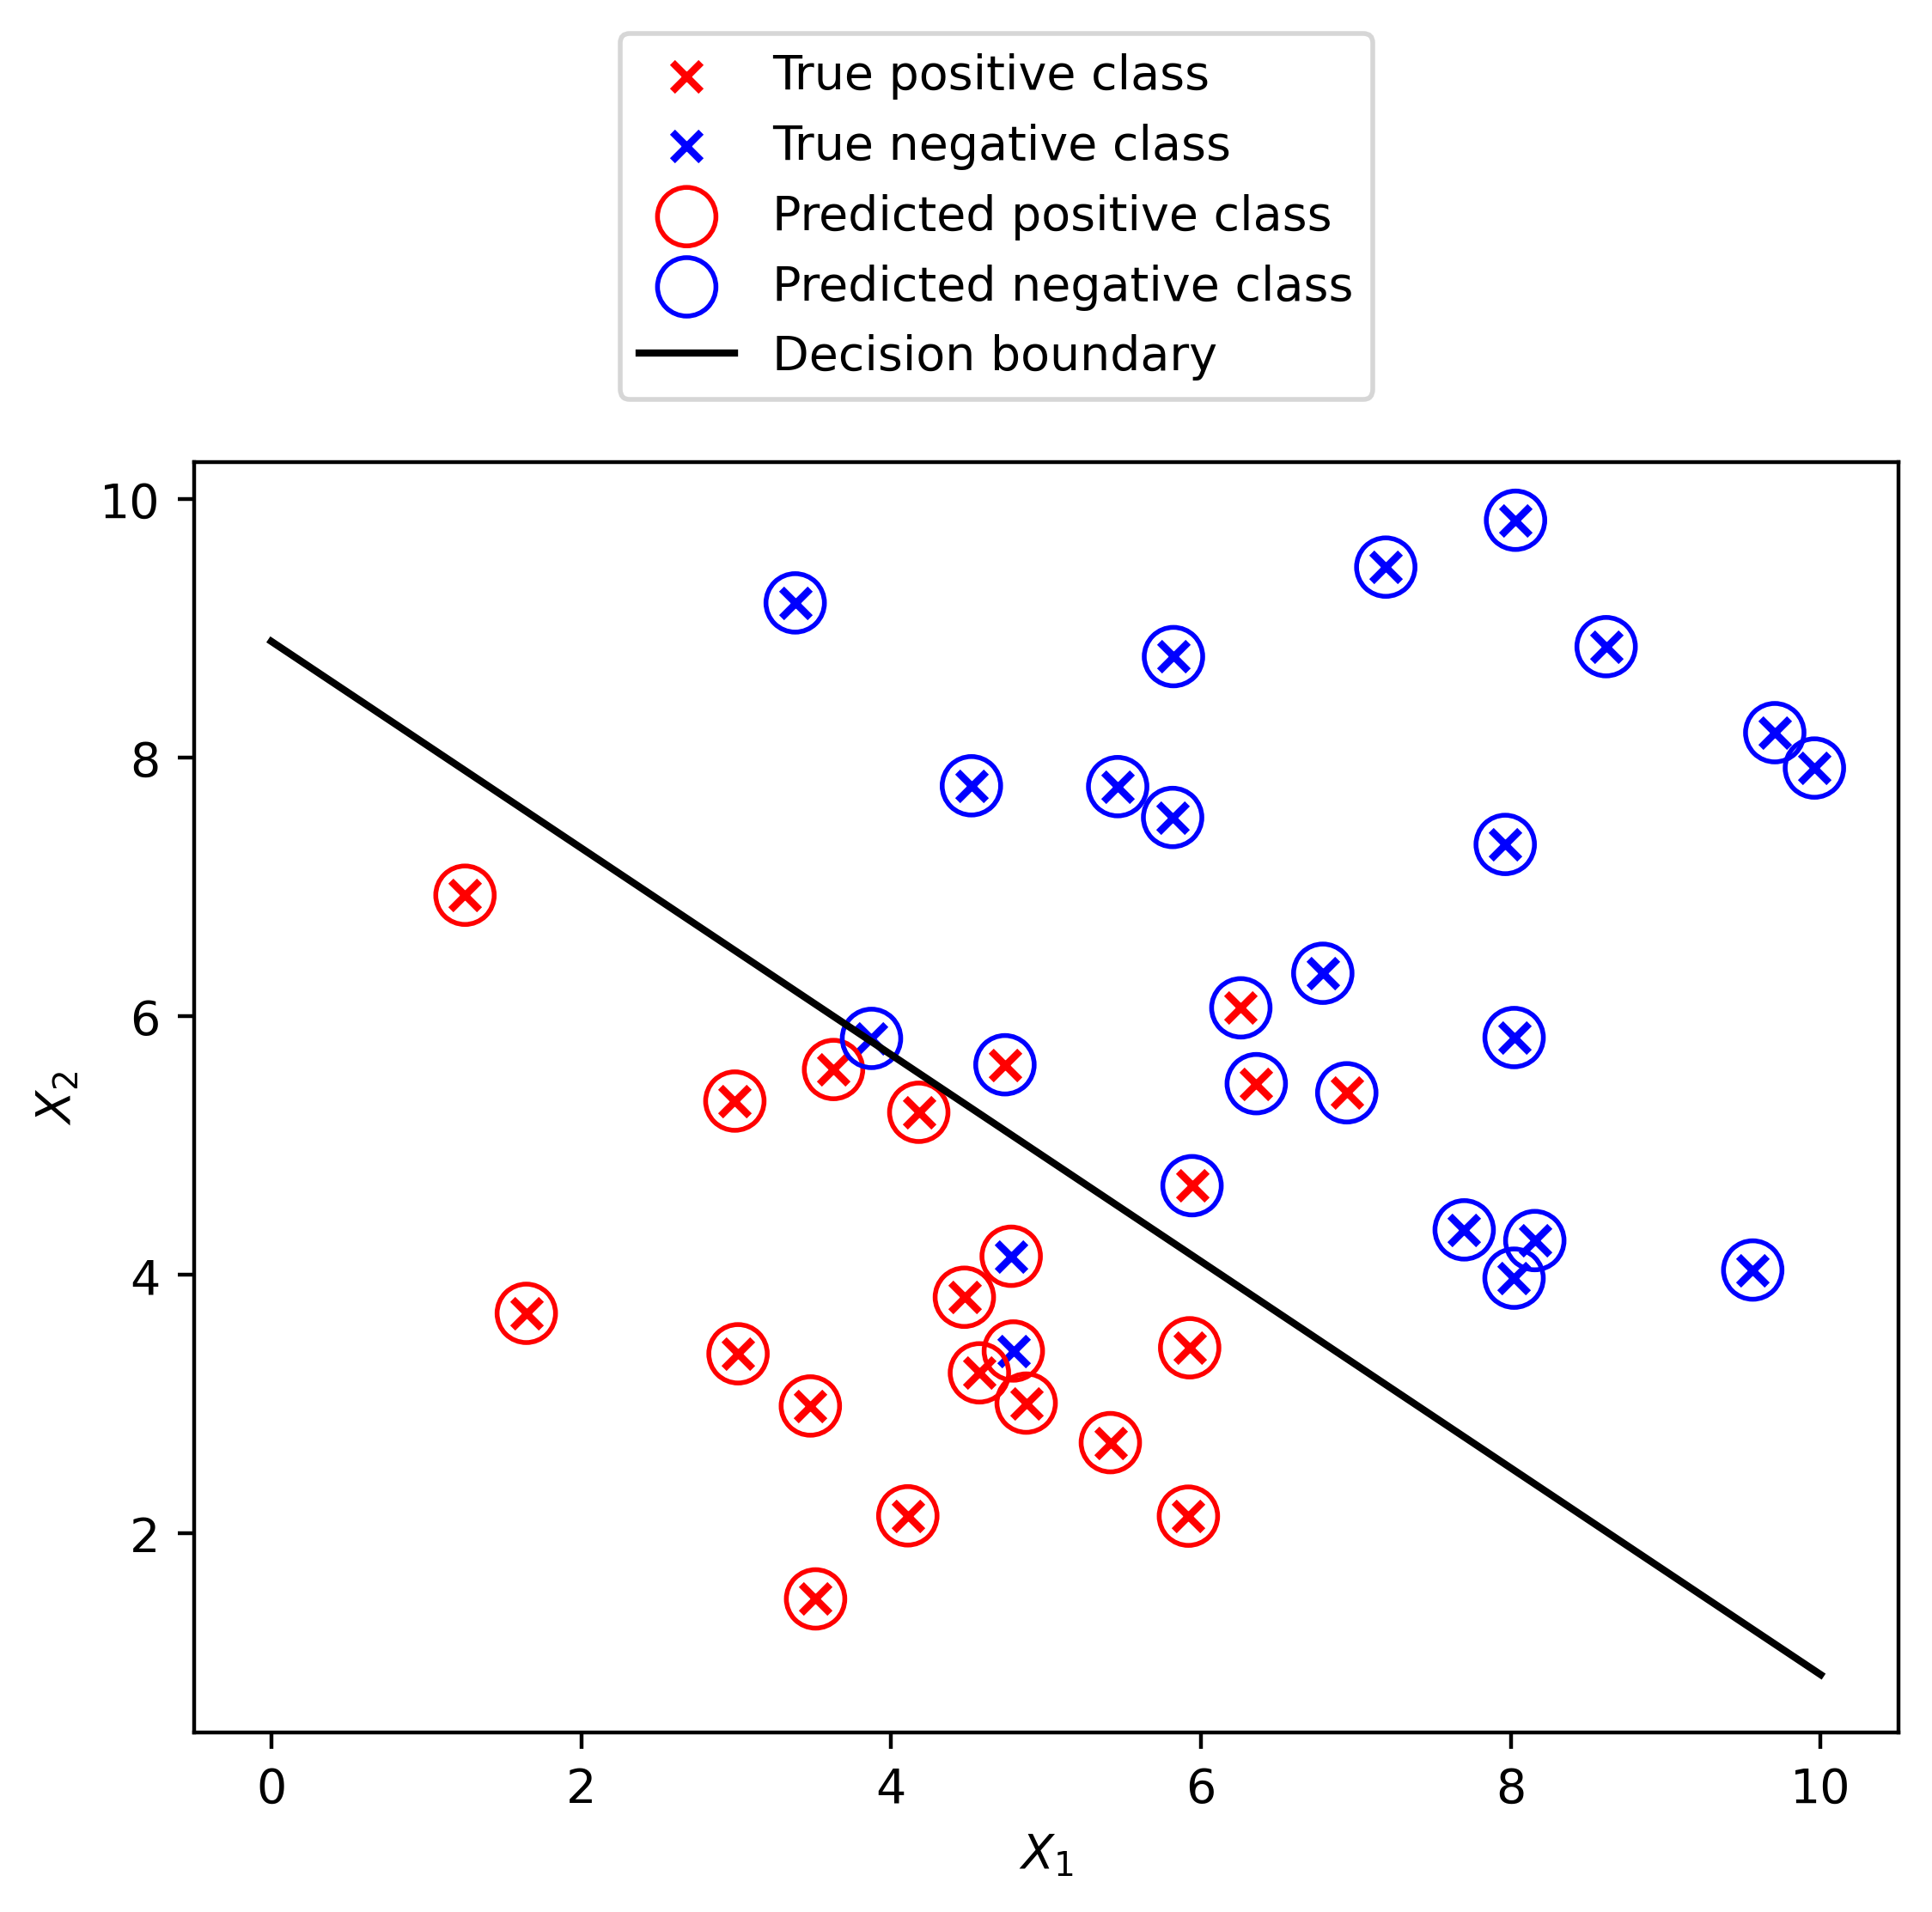

In [48]:
pos_true = plt.scatter(X_1_pos, X_2_pos, color='red', marker='x', label = 'True positive class')

neg_true = plt.scatter(X_1_neg, X_2_neg, color='blue', marker='x', label = 'True negative class')

pos_pred = plt.scatter(X[positive_indices, 0], X[positive_indices, 1], facecolors='none', edgecolors='red', s=150, marker='o', label = 'Predicted positive class')

neg_pred = plt.scatter(X[negative_indices, 0], X[negative_indices, 1], facecolors='none', edgecolors='blue', s=150, marker='o', label = 'Predicted negative class')

dec = plt.plot(X_1_decision_boundary, X_2_decision_boundary, 'k-', label = 'Decision boundary')

plt.xlabel('$X_1$')
plt.ylabel('$X_2$')

plt.legend(loc=[0.25, 1.05])
